In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import time

# 1) Load & preprocess Letter data
X, y = fetch_openml('letter', version=1, return_X_y=True, as_frame=False)
scaler = StandardScaler()
X = scaler.fit_transform(X.astype(np.float32))

le = LabelEncoder()
y = le.fit_transform(y)  # maps 'A'–'Z' → 0–25

# train/test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# wrap in PyTorch datasets
train_ds = TensorDataset(
    torch.from_numpy(X_tr), 
    torch.from_numpy(y_tr).long()
)
test_ds = TensorDataset(
    torch.from_numpy(X_te), 
    torch.from_numpy(y_te).long()
)

Dataset: UCI Letter Recognition
Total samples: 20000
Features: 16
Classes: 26 (Letters A-Z)
Training samples: 16000
Test samples: 4000


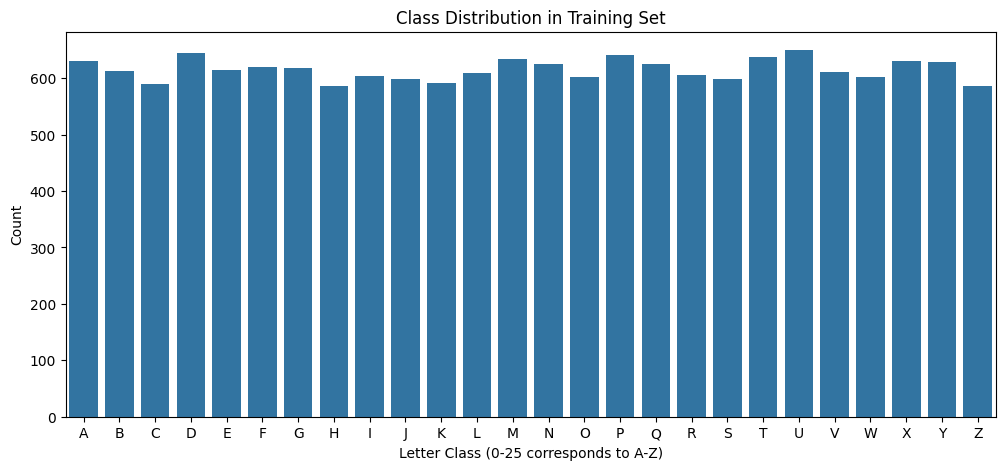

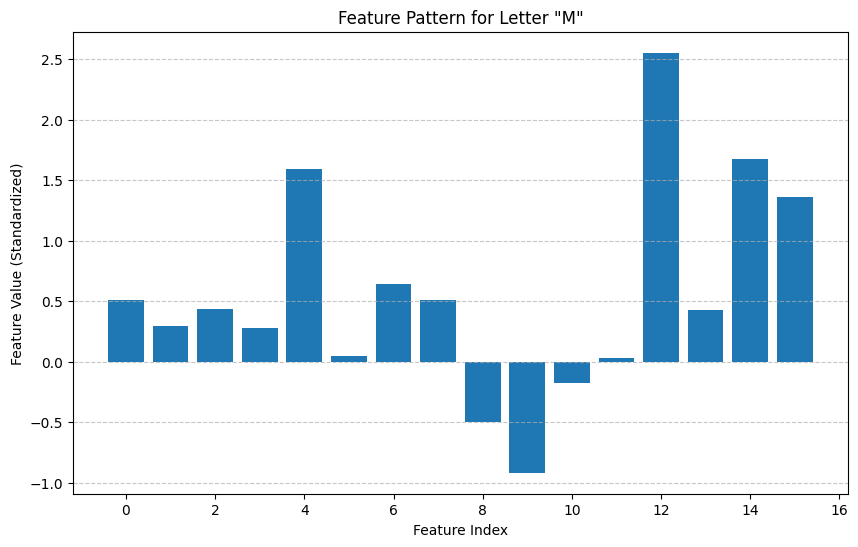

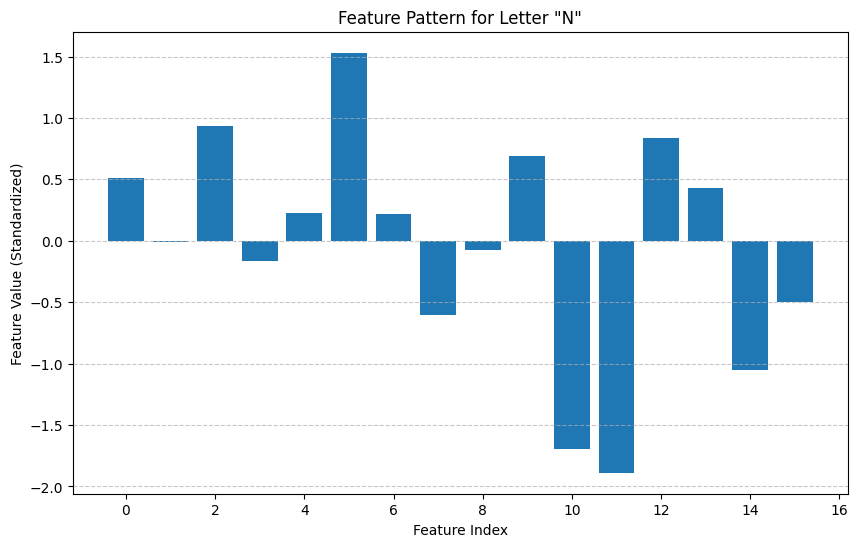

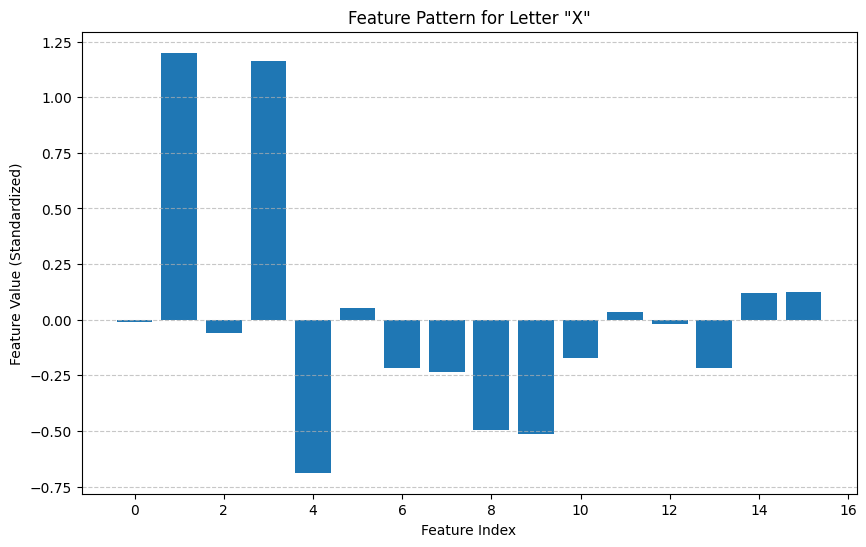

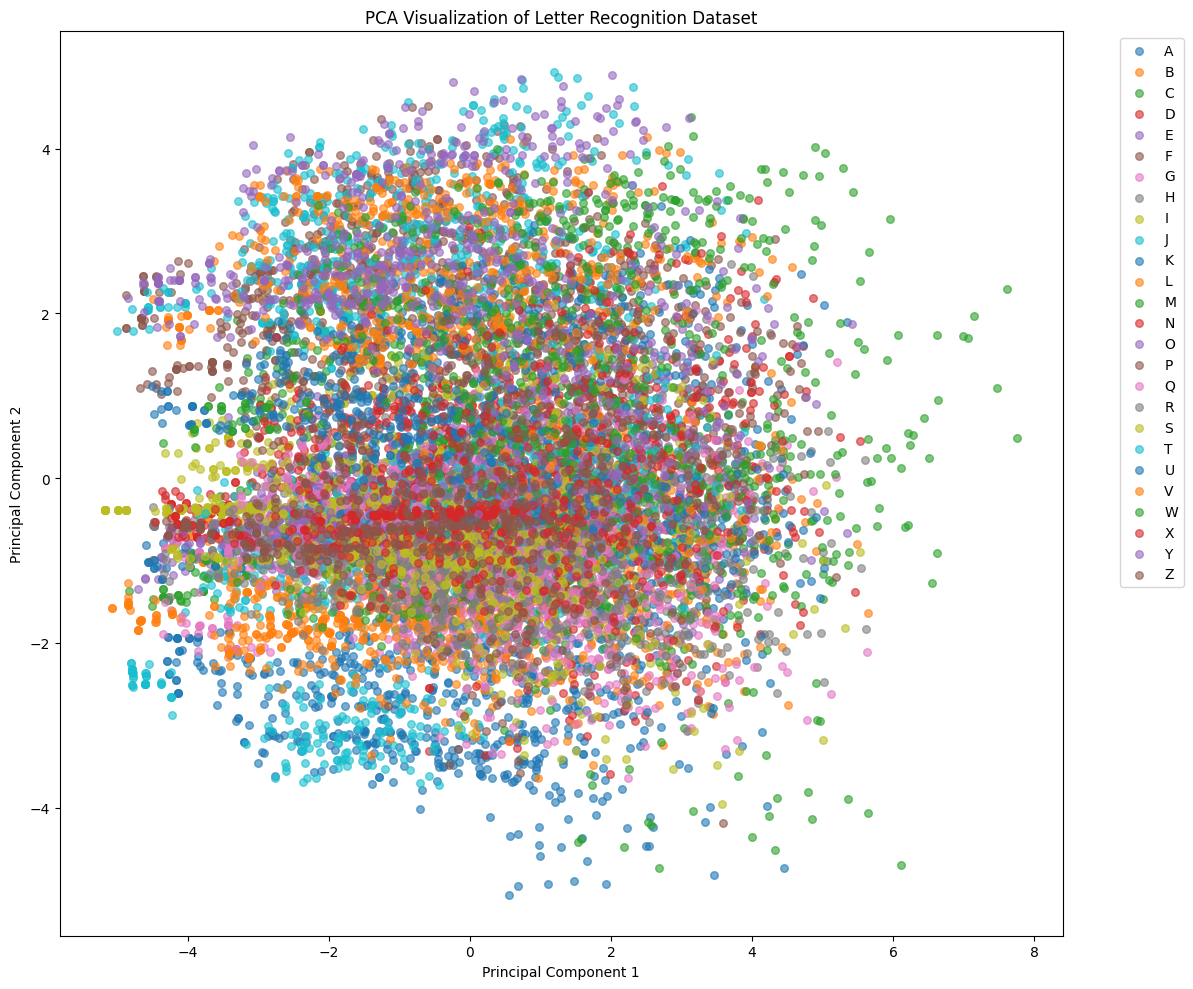

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Display dataset information
print(f"Dataset: UCI Letter Recognition")
print(f"Total samples: {len(X)}")
print(f"Features: {X.shape[1]}")
print(f"Classes: {len(np.unique(y))} (Letters A-Z)")
print(f"Training samples: {len(X_tr)}")
print(f"Test samples: {len(X_te)}")

# Note: The UCI Letter Recognition dataset doesn't contain actual images
# It contains 16 numerical features extracted from letter images
# We can visualize these features or use dimensionality reduction to plot them

# Display class distribution
plt.figure(figsize=(12, 5))
sns.countplot(x=y_tr, order=range(26))
plt.title('Class Distribution in Training Set')
plt.xlabel('Letter Class (0-25 corresponds to A-Z)')
plt.ylabel('Count')
plt.xticks(range(26), le.inverse_transform(range(26)))
plt.show()

# Visualize feature patterns for a few samples
def plot_letter_features(X_sample, y_sample, idx):
    plt.figure(figsize=(10, 6))
    features = X_sample[idx].reshape(1, -1)
    letter = le.inverse_transform([y_sample[idx]])[0]
    
    # Plot the 16 features as a bar chart
    plt.bar(range(16), features[0])
    plt.title(f'Feature Pattern for Letter "{letter}"')
    plt.xlabel('Feature Index')
    plt.ylabel('Feature Value (Standardized)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Plot features for a few random samples
for i in np.random.choice(len(y_tr), 3, replace=False):
    plot_letter_features(X_tr, y_tr, i)

# Visualize the dataset in 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_tr)

plt.figure(figsize=(12, 10))
for i in range(26):
    letter = le.inverse_transform([i])[0]
    mask = y_tr == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=letter, alpha=0.6, s=30)

plt.title('PCA Visualization of Letter Recognition Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Plan

Run grid search 3 times at approx 30 hrs per. make this the 'true' values for our samples

for each other algorithm, run 3 times each for hp computation. Give a total of 1.5 hours per algorithm to find best computation using parallel (because CPU is very slow)

Our hyperband: 68 mins per 45 jobs if red = 3. 90 mins / 68 (min per 68 job) * 45 jobs = approx 60 total iterations (edited to 45 again with final epoch run)

7799 / 28 * 1.5 = 417 approx 425

Random: 450 configs -> 1.25 HRS 

TPE: 450 configs -> 2 HRS * (0.75) approx 330

CMAES: 450 configs -> 1.1 hrs * (1.5/1.1) approx 625

GP: 300 configs -> 1.05 hrs * 1.5 / 1.05 approx 425

In [14]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import optuna
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tqdm.auto import tqdm
import json
import matplotlib.pyplot as plt
import time

# 6) Create Hyperband study
import sys
import os

# Add the hyperband_sampler directory to Python path
current_dir = os.getcwd()
print(f"Current directory: {current_dir}")

# Go up to HPOptimization root directory  
root_dir = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))
print(f"Root directory: {root_dir}")

# Add hyperband_sampler to path
hyperband_path = os.path.join(root_dir, "hyperband_sampler")
print(f"Adding to path: {hyperband_path}")

if hyperband_path not in sys.path:
    sys.path.append(hyperband_path)

seeds = [0,100,200,300]

# Now import the class
from hyperband_study import HyperbandStudy

for i in [1,2,3]:
    # 1) Grid definition
    param_grid = {
        "n_layers":      [1, 2, 3],
        "n_units_l0":    list(range(32, 257, 42)),
        "n_units_l1":    list(range(32, 257, 42)),
        "n_units_l2":    list(range(32, 257, 42)),
        "batch_size":    list(range(32, 257, 64)),
        "learning_rate": [1e-4, 1e-3, 1e-2],
    }

    # 2) Data prep
    X, y = fetch_openml('letter', version=1, return_X_y=True, as_frame=False)
    X = StandardScaler().fit_transform(X.astype('float32'))
    y = LabelEncoder().fit_transform(y)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=i
    )
    train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
    test_ds  = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te))
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 3) Model
    class OptunaLetterNet(nn.Module):
        def __init__(self, trial):
            super().__init__()
            n_layers = trial.suggest_categorical("n_layers", param_grid["n_layers"])
            hidden = []
            if n_layers >= 1:
                hidden.append(trial.suggest_categorical("n_units_l0", param_grid["n_units_l0"]))
            if n_layers >= 2:
                hidden.append(trial.suggest_categorical("n_units_l1", param_grid["n_units_l1"]))
            if n_layers >= 3:
                hidden.append(trial.suggest_categorical("n_units_l2", param_grid["n_units_l2"]))
            layers = []
            in_dim = 16
            for h in hidden:
                layers.append(nn.Linear(in_dim, h)); in_dim = h
            self.layers = nn.ModuleList(layers)
            self.output = nn.Linear(in_dim, 26)
            self.activation = F.relu
        def forward(self, x):
            for layer in self.layers:
                x = self.activation(layer(x))
            return self.output(x)

    # 4) Objective (modified for Hyperband)
    def objective(trial):
        model = OptunaLetterNet(trial).to(device)
        lr = trial.suggest_categorical("learning_rate", param_grid["learning_rate"])
        bs = trial.suggest_categorical("batch_size", param_grid["batch_size"])
        
        # Resource parameter controlled by Hyperband
        epochs = trial.suggest_int("resource", 1, 100)
        
        train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
        test_loader  = DataLoader(test_ds, batch_size=bs, shuffle=False)
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.CrossEntropyLoss(reduction='sum')
        
        # Train for the number of epochs determined by Hyperband
        for _ in range(int(epochs)):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()
        
        # Evaluate
        model.eval()
        correct = total = 0
        losses = []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                preds = outputs.argmax(dim=1)
                loss = loss_fn(outputs, yb).item()
                losses.append(loss)
                correct += (preds == yb).sum().item()
                total   += yb.size(0)
        accuracy = correct / total
        avg_loss = sum(losses) / total
        trial.set_user_attr('loss', avg_loss)
        return accuracy

    optuna.logging.set_verbosity(optuna.logging.WARNING)

    r = 5
    # 6) Create Hyperband study
    hyperband_study = HyperbandStudy( #approx 1.5 hours total
        directions="maximize",
        min_resource=3, 
        max_resource=30, 
        reduction_factor=r,
        hyperband_iterations=55,
        sampler_seed=seeds[i]
    )

    # Show bracket structure
    print("Hyperband bracket structure:")
    print(f"Total trials needed: {hyperband_study.n_trials}")
    for j, bracket in enumerate(hyperband_study.sampler._brackets):
        print(f"Bracket {j}: {len(bracket['rungs'])} rungs")
        for k, rung in enumerate(bracket['rungs']):
            print(f"  Rung {k}: {rung['n_configs']} trials × {rung['resource']} epochs")

    # 7) Prepare logging and run optimization
    results = []
    pbar = tqdm(total=hyperband_study.n_trials, desc="Hyperband Optimization")

    def logging_callback(study, trial):
    # record this trial's params + value
        entry = trial.params.copy()
        entry["accuracy"] = trial.value
        entry["trial_number"] = trial.number
        entry["trial_end"] = time.time()
        entry["loss"] = trial.user_attrs['loss']
        results.append(entry)
        pbar.update(1)

    # Add callback and run
    study = hyperband_study.optimize(objective=objective, callbacks=[logging_callback], n_jobs=-1)  # This handles TrialPruned gracefully
    pbar.close()

    # 8) Save results to JSON
    with open(f"results/HYPERBAND/n={r}/results_{i}.json", "w") as f:
        json.dump(results, f, indent=2)

Current directory: c:\Users\16073\HPOptimization\WIP\phase2\UCILetterReconigition
Root directory: c:\Users\16073\HPOptimization
Adding to path: c:\Users\16073\HPOptimization\hyperband_sampler
Hyperband bracket structure:
Total trials needed: 550
Bracket 0: 3 rungs
  Rung 0: 5 trials × 3 epochs
  Rung 1: 1 trials × 15 epochs
  Rung 2: 1 trials × 30 epochs
Bracket 1: 2 rungs
  Rung 0: 2 trials × 15 epochs
  Rung 1: 1 trials × 30 epochs


Hyperband Optimization:   0%|          | 0/550 [00:00<?, ?it/s]

Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all br

Hyperband Optimization:   0%|          | 0/550 [00:00<?, ?it/s]

Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all br

Hyperband Optimization:   0%|          | 0/550 [00:00<?, ?it/s]

Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all br

In [19]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import optuna
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tqdm.auto import tqdm
import json

    
seeds = [1,2,3]
iter = 1
# 1) Grid definition
param_grid = {
    "n_layers":      [1, 2, 3],
    "n_units_l0":    list(range(32, 257, 42)),
    "n_units_l1":    list(range(32, 257, 42)),
    "n_units_l2":    list(range(32, 257, 42)),
    "batch_size":    list(range(32, 257, 64)),
    "learning_rate": [1e-4, 1e-3, 1e-2],
}

# 2) Data prep
X, y = fetch_openml('letter', version=1, return_X_y=True, as_frame=False)
X = StandardScaler().fit_transform(X.astype('float32'))
y = LabelEncoder().fit_transform(y)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=iter
)
train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
test_ds  = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3) Model
class OptunaLetterNet(nn.Module):
    def __init__(self, trial):
        super().__init__()
        n_layers = trial.suggest_int("n_layers", param_grid["n_layers"][0], param_grid["n_layers"][-1])
        hidden = []
        if n_layers >= 1:
            hidden.append(trial.suggest_int("n_units_l0", param_grid["n_units_l0"][0], param_grid["n_units_l0"][-1], step=42))
        if n_layers >= 2:
            hidden.append(trial.suggest_int("n_units_l1", param_grid["n_units_l1"][0], param_grid["n_units_l1"][-1], step=42))
        if n_layers >= 3:
            hidden.append(trial.suggest_int("n_units_l2", param_grid["n_units_l2"][0], param_grid["n_units_l2"][-1], step=42))
        layers = []
        in_dim = 16
        for h in hidden:
            layers.append(nn.Linear(in_dim, h)); in_dim = h
        self.layers = nn.ModuleList(layers)
        self.output = nn.Linear(in_dim, 26)
        self.activation = F.relu
    def forward(self, x):
        for layer in self.layers:
            x = self.activation(layer(x))
        return self.output(x)

# 4) Objective
def objective(trial):
    model = OptunaLetterNet(trial).to(device)
    lr = trial.suggest_categorical("learning_rate", param_grid["learning_rate"])
    bs = trial.suggest_int("batch_size", param_grid["batch_size"][0], param_grid["batch_size"][-1], step=64)
    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=bs, shuffle=False)
    opt          = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn      = nn.CrossEntropyLoss(reduction='sum')
    for _ in range(30):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()
    model.eval()
    correct = total = 0
    losses = []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            preds = outputs.argmax(dim=1)
            loss = loss_fn(outputs, yb).item()
            losses.append(loss)
            correct += (preds == yb).sum().item()
            total   += yb.size(0)
    accuracy = correct / total
    avg_loss = sum(losses) / total
    trial.set_user_attr('loss', avg_loss)
    return accuracy

# 6) Prepare logging structures
results = []
def logging_callback(study, trial):
    # record this trial's params + value
    entry = trial.params.copy()
    entry["accuracy"] = trial.value
    entry["trial_number"] = trial.number
    entry["trial_end"] = time.time()
    entry["loss"] = trial.user_attrs['loss']
    results.append(entry)
    pbar.update(1)

In [6]:
import time
import json
from tqdm.auto import tqdm
from optuna.samplers import GridSampler
from sklearn.model_selection import ParameterGrid

results = []
iter = 3
sampler = GridSampler(param_grid)
study   = optuna.create_study(direction="maximize", sampler=sampler)
n_trials = len(list(ParameterGrid(param_grid)))
print(f"Running full grid of {n_trials} configs…")
pbar = tqdm(total=n_trials, desc="Grid Search")

results.append({"start_time": time.time()})
study.optimize(
    objective,
    n_trials=n_trials,
    n_jobs=6,
    callbacks=[logging_callback],
)
pbar.close()

# 8) Save results to JSON or CSV
with open(f"results/GRID/results_{iter}.json", "w") as f:
    json.dump(results, f, indent=2)

# 9) Best result
print("Best accuracy:", study.best_value)
print("Best hyperparams:", study.best_trial.params)


Running full grid of 7776 configs…


Grid Search:   0%|          | 0/7776 [00:00<?, ?it/s]

Best accuracy: 0.96675
Best hyperparams: {'n_layers': 3, 'n_units_l0': 242, 'n_units_l1': 242, 'n_units_l2': 158, 'learning_rate': 0.001, 'batch_size': 32}


In [8]:

import optuna
from optuna.samplers import RandomSampler
from tqdm.auto import tqdm
import time

iter = 3
seeds = [0,1,2,3]
sampler = RandomSampler(seed=seeds[iter])
study = optuna.create_study(direction="maximize", sampler=sampler)
n_trials = 450 # 450
print(f"Running Random Search of {n_trials} configs…")

# 6) Prepare logging structures
results = []
pbar = tqdm(total=n_trials, desc="Random Search")

results.append({"start_time": time.time()})
optuna.logging.set_verbosity(optuna.logging.WARNING)
# 7) Run optimization in parallel
study.optimize(
    objective,
    n_trials=n_trials,
    n_jobs=6,
    callbacks=[logging_callback]
)
pbar.close()

# 8) Save results to JSON or CSV
with open(f"results/RANDOM/results_{iter}.json", "w") as f:
    json.dump(results, f, indent=2)

# 9) Best result
print("Best accuracy:", study.best_value)
print("Best hyperparams:", study.best_trial.params)



Running Random Search of 450 configs…


Random Search:   0%|          | 0/450 [00:00<?, ?it/s]

Best accuracy: 0.963
Best hyperparams: {'n_layers': 2, 'n_units_l0': 242, 'n_units_l1': 200, 'learning_rate': 0.01, 'batch_size': 160}


In [12]:

# 5) Study + GridSampler
import optuna
from optuna.samplers import TPESampler  
from tqdm.auto import tqdm
import time

iter = 3
seeds = [0,4,5,6]
sampler = TPESampler(n_startup_trials=25)
study = optuna.create_study(direction="maximize", sampler=sampler)
n_trials = 270 # 270
print(f"Running TPE of {n_trials} configs…")

# 6) Prepare logging structures
results = []
pbar = tqdm(total=n_trials, desc="TPE Search")

results.append({"start_time": time.time()})
optuna.logging.set_verbosity(optuna.logging.WARNING)
# 7) Run optimization in parallel
study.optimize(
    objective,
    n_trials=n_trials,
    n_jobs=6,
    callbacks=[logging_callback],
)
pbar.close()

# 8) Save results to JSON or CSV
with open(f"results/TPE/results_{iter}.json", "w") as f:
    json.dump(results, f, indent=2)

# 9) Best result
print("Best accuracy:", study.best_value)
print("Best hyperparams:", study.best_trial.params)



Running TPE of 270 configs…


TPE Search:   0%|          | 0/270 [00:00<?, ?it/s]

Best accuracy: 0.9705
Best hyperparams: {'n_layers': 2, 'n_units_l0': 242, 'n_units_l1': 242, 'learning_rate': 0.001, 'batch_size': 32}


In [20]:

# 5) Study + GridSampler
# 5) Study + CmaEsSampler
import optuna
from optuna.samplers import CmaEsSampler  
from tqdm.auto import tqdm
import time
import subprocess
import sys

iter = 1
seeds = [0,7,8,9]
sampler = CmaEsSampler(           
    sigma0=0.3,   # random number, compare to min range / 6
)

study = optuna.create_study(direction="maximize", sampler=sampler)
n_trials = 625 # 625
print(f"Running full CMaEs of {n_trials} configs…")

# 6) Prepare logging structures
results = []
pbar = tqdm(total=n_trials, desc="CMAES Search")

results.append({"start_time": time.time()})
optuna.logging.set_verbosity(optuna.logging.WARNING)
# 7) Run optimization in parallel
study.optimize(
    objective,
    n_trials=n_trials,
    n_jobs=6,
    callbacks=[logging_callback]
)
pbar.close()

# 8) Save results to JSON or CSV
with open(f"results/CMAES/results_{iter}.json", "w") as f:
    json.dump(results, f, indent=2)

# 9) Best result
print("Best accuracy:", study.best_value)
print("Best hyperparams:", study.best_trial.params)

Running full CMaEs of 625 configs…


CMAES Search:   0%|          | 0/625 [00:00<?, ?it/s]

[W 2025-06-12 16:26:27,149] The parameter 'learning_rate' in trial#6 is sampled independently by using `RandomSampler` instead of `CmaEsSampler` (optimization performance may be degraded). `CmaEsSampler` does not support dynamic search space or `CategoricalDistribution`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler`, if this independent sampling is intended behavior.
[W 2025-06-12 16:26:35,967] The parameter 'learning_rate' in trial#7 is sampled independently by using `RandomSampler` instead of `CmaEsSampler` (optimization performance may be degraded). `CmaEsSampler` does not support dynamic search space or `CategoricalDistribution`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler`, if this independent sampling is intended behavior.
[W 2025-06-12 16:26:36,659] The parameter 'learning_rate' in trial#8 is sampled independently by using `RandomSampler`

Best accuracy: 0.9655
Best hyperparams: {'n_layers': 2, 'n_units_l0': 158, 'n_units_l1': 242, 'learning_rate': 0.01, 'batch_size': 224}


In [16]:

# 5) Study + GridSampler
import optuna
from optuna.samplers import GPSampler         
from tqdm.auto import tqdm
import time
import torch

iter = 2
seeds = [0,9,10,11]
sampler = GPSampler(deterministic_objective=True)
study = optuna.create_study(direction="maximize", sampler=sampler)
n_trials = 425 # 425

# 6) Prepare logging structures
results = []
pbar = tqdm(total=n_trials, desc="GP Search")

results.append({"start_time": time.time()})
optuna.logging.set_verbosity(optuna.logging.WARNING)
# 7) Run optimization in parallel
study.optimize(
    objective,
    n_trials=n_trials,
    n_jobs=6,
    callbacks=[logging_callback],
)
pbar.close()

# 8) Save results to JSON or CSV
with open(f"results/GP/results_{iter}.json", "w") as f:
    json.dump(results, f, indent=2)

# 9) Best result
print("Best accuracy:", study.best_value)
print("Best hyperparams:", study.best_trial.params)



C:\Users\16073\AppData\Local\Temp\ipykernel_25168\933860623.py:10: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  sampler = GPSampler(deterministic_objective=True)


GP Search:   0%|          | 0/425 [00:00<?, ?it/s]

Best accuracy: 0.96975
Best hyperparams: {'n_layers': 2, 'n_units_l0': 242, 'n_units_l1': 242, 'learning_rate': 0.001, 'batch_size': 32}


Grid Search Analysis (Best Possible Configuration)
Best accuracy: 0.9712
Best loss: 0.1130
Configuration (Best Accuracy):
  n_layers: 2
  n_units_l0: 200
  n_units_l1: 242
  learning_rate: 0.001
  batch_size: 32

Lowest Loss Configuration:
Accuracy: 0.9685
Loss: 0.1108
Configuration (Lowest Loss):
  n_layers: 2
  n_units_l0: 242
  n_units_l1: 242
  learning_rate: 0.001
  batch_size: 32


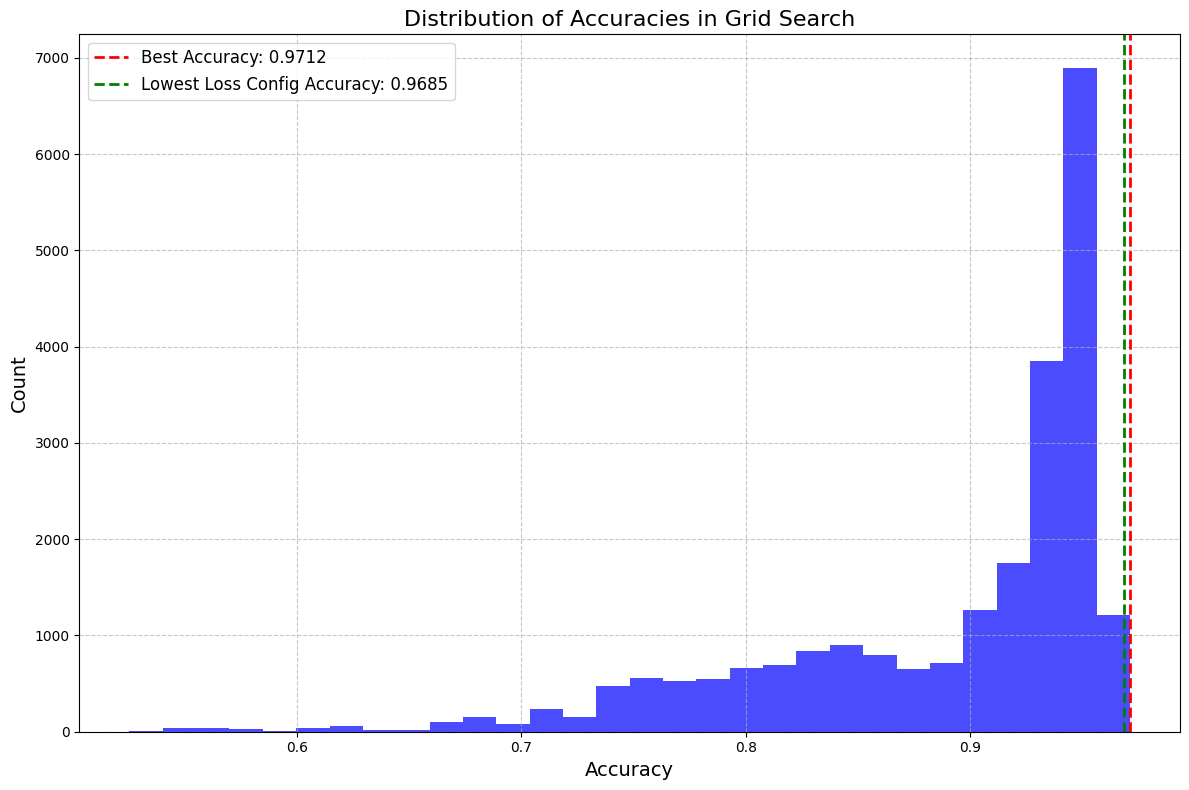

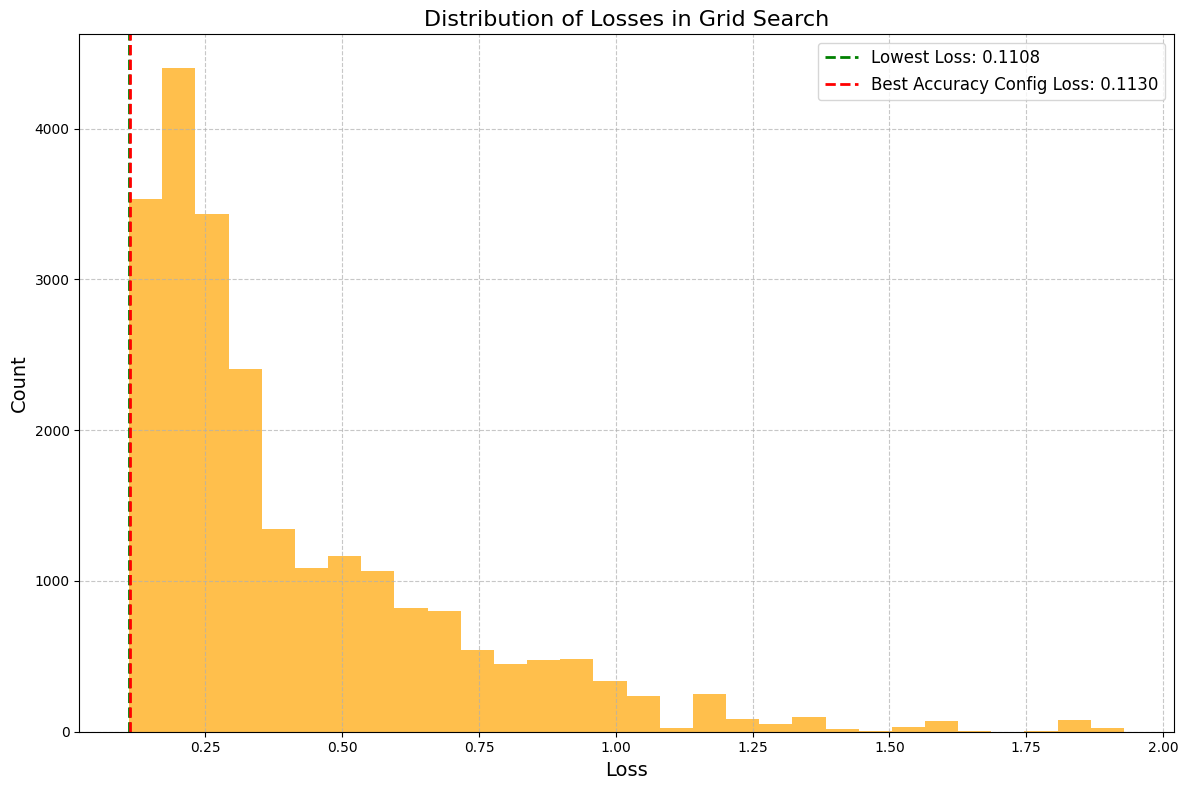

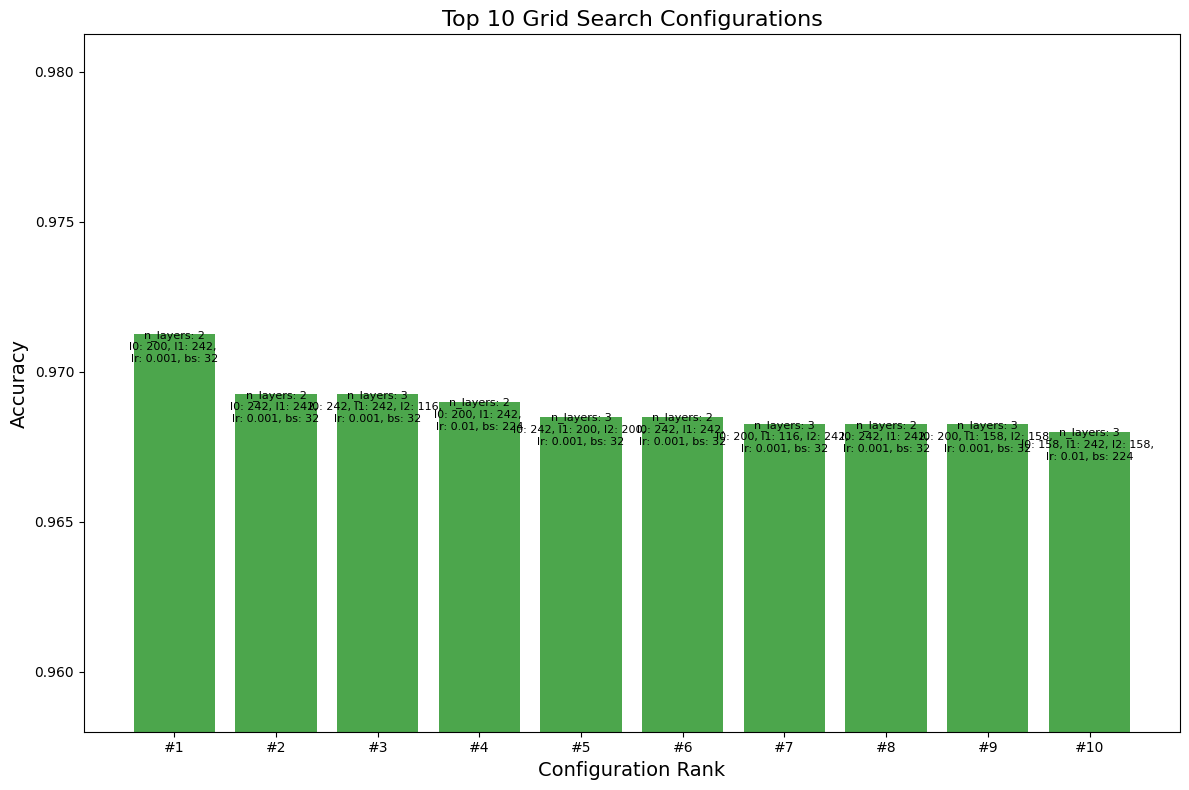

In [6]:
# Analyze Grid Search results to find best possible accuracy
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Load all grid search results
grid_results = []
for i in range(1, 4):  # results_1, results_2, results_3
    try:
        with open(f"results/grid/results_{i}.json", "r") as f:
            results = json.load(f)
            grid_results.extend(results[1:])  # Skip the first element (metadata)
    except FileNotFoundError:
        print(f"Warning: results/grid/results_{i}.json not found")

if grid_results:
    # Extract accuracies and configurations
    accuracies = [result.get("accuracy", 0) for result in grid_results]
    losses = [result.get("loss", float('inf')) for result in grid_results]
    
    # Find best accuracy configuration
    best_acc_idx = np.argmax(accuracies)
    best_acc_config = grid_results[best_acc_idx]
    
    # Find lowest loss configuration
    best_loss_idx = np.argmin(losses)
    best_loss_config = grid_results[best_loss_idx]
    
    print("Grid Search Analysis (Best Possible Configuration)")
    print(f"Best accuracy: {best_acc_config['accuracy']:.4f}")
    print(f"Best loss: {best_acc_config['loss']:.4f}")
    print("Configuration (Best Accuracy):")
    for key, value in best_acc_config.items():
        if key not in ["accuracy", "loss", "trial_number", "trial_end"]:
            print(f"  {key}: {value}")
    
    print("\nLowest Loss Configuration:")
    print(f"Accuracy: {best_loss_config['accuracy']:.4f}")
    print(f"Loss: {best_loss_config['loss']:.4f}")
    print("Configuration (Lowest Loss):")
    for key, value in best_loss_config.items():
        if key not in ["accuracy", "loss", "trial_number", "trial_end"]:
            print(f"  {key}: {value}")
    
    # Plot distribution of accuracies
    plt.figure(figsize=(12, 8))
    plt.hist(accuracies, bins=30, alpha=0.7, color='blue')
    plt.axvline(best_acc_config['accuracy'], color='red', linestyle='dashed', linewidth=2, 
                label=f'Best Accuracy: {best_acc_config["accuracy"]:.4f}')
    plt.axvline(best_loss_config['accuracy'], color='green', linestyle='dashed', linewidth=2, 
                label=f'Lowest Loss Config Accuracy: {best_loss_config["accuracy"]:.4f}')
    plt.xlabel("Accuracy", fontsize=14)
    plt.ylabel("Count", fontsize=14)
    plt.title("Distribution of Accuracies in Grid Search", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # Plot distribution of losses
    plt.figure(figsize=(12, 8))
    plt.hist(losses, bins=30, alpha=0.7, color='orange')
    plt.axvline(best_loss_config['loss'], color='green', linestyle='dashed', linewidth=2, 
                label=f'Lowest Loss: {best_loss_config["loss"]:.4f}')
    plt.axvline(best_acc_config['loss'], color='red', linestyle='dashed', linewidth=2, 
                label=f'Best Accuracy Config Loss: {best_acc_config["loss"]:.4f}')
    plt.xlabel("Loss", fontsize=14)
    plt.ylabel("Count", fontsize=14)
    plt.title("Distribution of Losses in Grid Search", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # Plot top 10 configurations
    top_indices = np.argsort(accuracies)[-10:][::-1]
    top_configs = [grid_results[i] for i in top_indices]
    top_accuracies = [grid_results[i]['accuracy'] for i in top_indices]
    
    plt.figure(figsize=(12, 8))
    plt.bar(range(len(top_accuracies)), top_accuracies, color='green', alpha=0.7)
    plt.xlabel("Configuration Rank", fontsize=14)
    plt.ylabel("Accuracy", fontsize=14)
    plt.title("Top 10 Grid Search Configurations", fontsize=16)
    plt.xticks(range(len(top_accuracies)), [f"#{i+1}" for i in range(len(top_accuracies))])
    plt.ylim(min(top_accuracies) - 0.01, max(top_accuracies) + 0.01)
    
    # Add configuration details as annotations
    for i, config in enumerate(top_configs):
        config_str = f"n_layers: {config.get('n_layers', 'N/A')}\n"
        for j in range(3):  # Assuming max 3 layers
            if f"n_units_l{j}" in config:
                config_str += f"l{j}: {config[f'n_units_l{j}']}, "
        config_str += f"\nlr: {config.get('learning_rate', 'N/A')}, bs: {config.get('batch_size', 'N/A')}"
        plt.annotate(config_str, (i, top_accuracies[i]), 
                    textcoords="offset points", xytext=(0,-20), 
                    ha='center', fontsize=8, rotation=0)
    
    plt.tight_layout()
    plt.show()
else:
    print("No grid search results found.")



Final Best Accuracies (averaged across all runs):
TPE: 0.9706
GP: 0.9688
CMAES: 0.9662
RANDOM: 0.9657
HYPERBAND: 0.9629


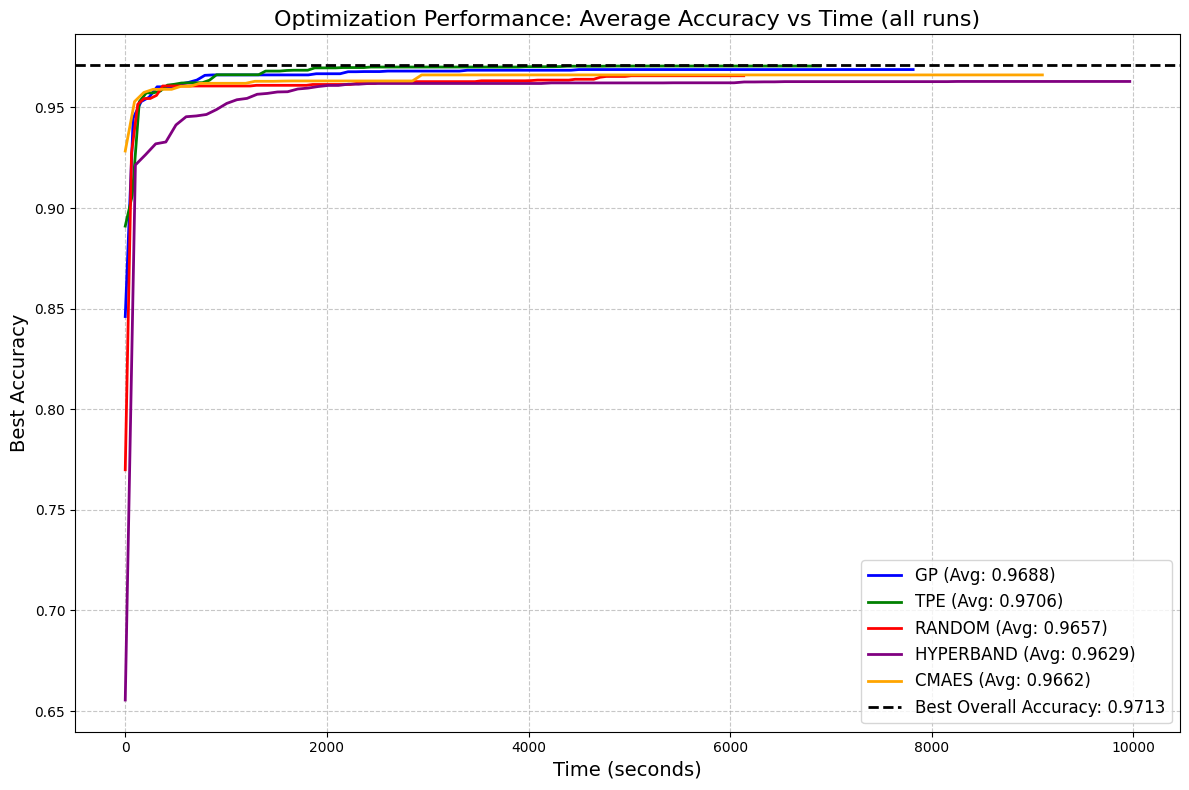


Final Best Losses (averaged across all runs):
TPE: 0.1140
GP: 0.1141
RANDOM: 0.1202
CMAES: 0.1202
HYPERBAND: 0.1245


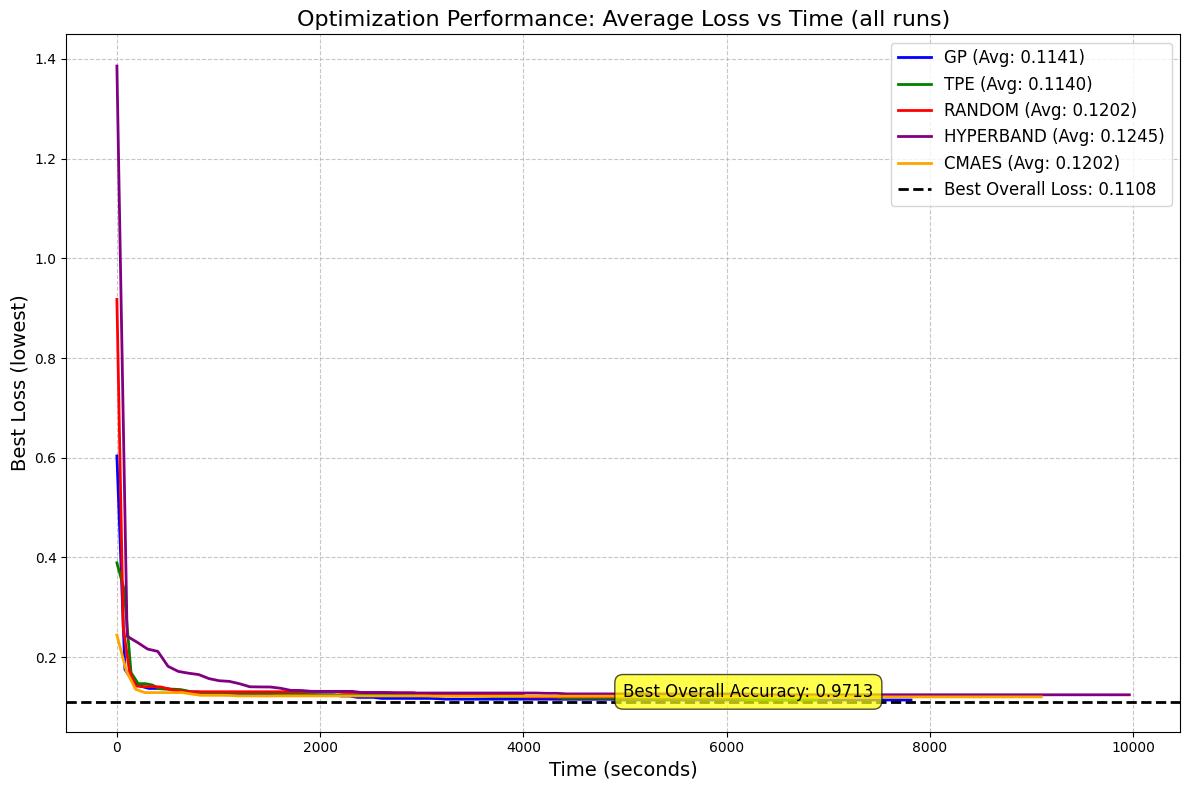

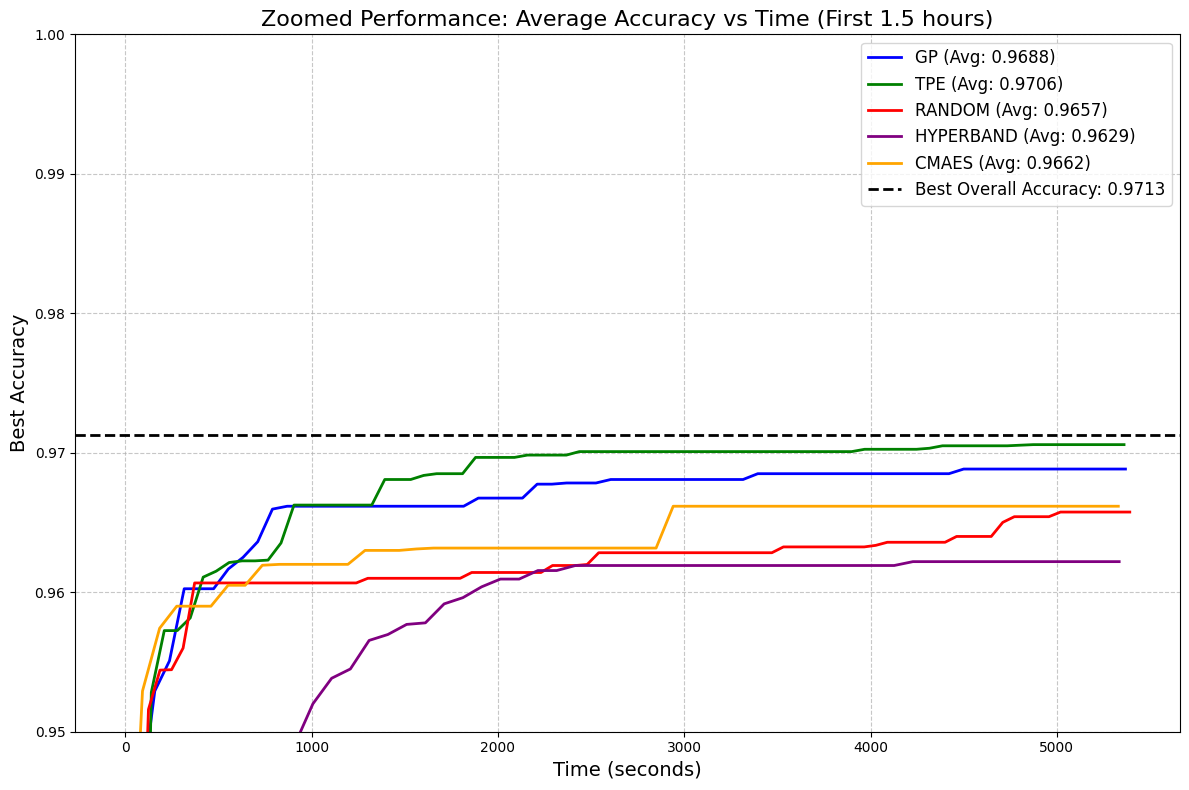

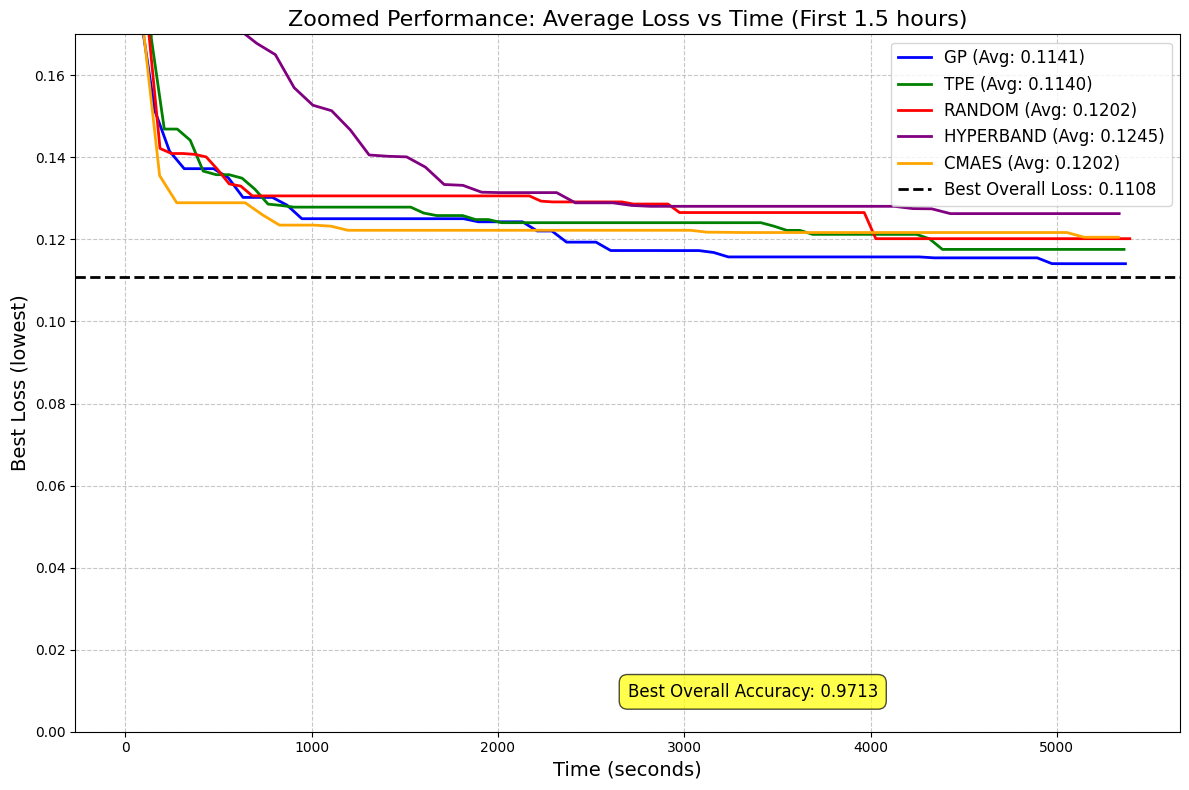

In [7]:
# Load and compare results from all optimization methods
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import defaultdict
from scipy.interpolate import interp1d

# Define the methods to compare
methods = ["GP", "TPE", "RANDOM", "HYPERBAND", "CMAES"]
colors = {
    "GP": "blue",
    "TPE": "green",
    "RANDOM": "red",
    "HYPERBAND": "purple",
    "CMAES": "orange"
}

# Function to load and combine results from multiple runs
def load_results(method):
    results_list = []
    
    # RANDOM still stored in original location
    if method == "RANDOM":
        try:
            for i in range(1, 4):  # Load results_1.json, results_2.json, results_3.json
                file_path = f"results/{method}/results_{i}.json"
                if os.path.exists(file_path):
                    with open(file_path, "r") as f:
                        results_list.append(json.load(f))
                else:
                    print(f"Warning: File not found - {file_path}")
        except Exception as e:
            print(f"Error loading {method} results: {e}")
    elif method == "HYPERBAND":
        # Load from all HYPERBAND folders
        try:
            for n in [2, 3, 4]:  # Different n values
                for i in range(1, 4):  # Load results_1.json, results_2.json, results_3.json
                    file_path = f"results/{method}/n={n}/results_{i}.json"
                    if os.path.exists(file_path):
                        with open(file_path, "r") as f:
                            results_list.append(json.load(f))
                    else:
                        print(f"Warning: File not found - {file_path}")
        except Exception as e:
            print(f"Error loading {method} results: {e}")
    else:
        # Other methods are stored in method/default/
        try:
            for i in range(1, 4):  # Load results_1.json, results_2.json, results_3.json
                file_path = f"results/{method}/default/results_{i}.json"
                if os.path.exists(file_path):
                    with open(file_path, "r") as f:
                        results_list.append(json.load(f))
                else:
                    print(f"Warning: File not found - {file_path}")
        except Exception as e:
            print(f"Error loading {method} results: {e}")
    
    return results_list

# Load results for each method
all_results = {}
for method in methods:
    results = load_results(method)
    if results:
        all_results[method] = results

# Function to extract time series data from a single run
def extract_time_series(results):
    if len(results) <= 1:  # Not enough data
        return None, None, None
    
    # First entry contains start_time
    if isinstance(results[0], dict) and "start_time" in results[0]:
        start_time = results[0]["start_time"]
        result_entries = results[1:]  # Skip the first entry with start_time
    else:
        # If first entry doesn't have start_time, use the first trial_end as reference
        start_time = min([r.get("trial_end", 0) for r in results if "trial_end" in r])
        result_entries = results
    
    times = []
    accuracies = []
    losses = []
    best_acc_so_far = 0
    best_loss_so_far = float('inf')
    
    for entry in result_entries:
        if "accuracy" in entry and "trial_end" in entry:
            rel_time = entry["trial_end"] - start_time
            acc = entry["accuracy"]
            loss = entry.get("loss", float('inf'))
            best_acc_so_far = max(best_acc_so_far, acc)
            best_loss_so_far = min(best_loss_so_far, loss)
            
            times.append(rel_time)
            accuracies.append(best_acc_so_far)
            losses.append(best_loss_so_far)
    
    # Sort by time to ensure proper plotting
    sorted_data = sorted(zip(times, accuracies, losses))
    if sorted_data:
        times, accuracies, losses = zip(*sorted_data)
        return times, accuracies, losses
    
    return None, None, None

# Process results for each method and average across runs
plot_data = {}
for method, results_list in all_results.items():
    # Find the best accuracy and loss across all runs
    best_accuracies = []
    best_losses = []
    time_series_data = []
    
    for results in results_list:
        times, accuracies, losses = extract_time_series(results)
        if times and accuracies and losses:
            time_series_data.append((times, accuracies, losses))
            best_accuracies.append(max(accuracies))
            best_losses.append(min(losses))
    
    if time_series_data:
        # Use the first run's time points as reference for interpolation
        ref_times = np.linspace(0, max([max(times) for times, _, _ in time_series_data]), 100)
        
        # Interpolate each run's data to the reference time points
        interp_accuracies = []
        interp_losses = []
        
        for times, accuracies, losses in time_series_data:
            if len(times) > 1:  # Need at least 2 points for interpolation
                acc_interp = interp1d(times, accuracies, bounds_error=False, fill_value=(accuracies[0], accuracies[-1]))
                loss_interp = interp1d(times, losses, bounds_error=False, fill_value=(losses[0], losses[-1]))
                
                interp_accuracies.append(acc_interp(ref_times))
                interp_losses.append(loss_interp(ref_times))
        
        # Average the interpolated curves
        if interp_accuracies and interp_losses:
            avg_accuracies = np.mean(interp_accuracies, axis=0)
            avg_losses = np.mean(interp_losses, axis=0)
            
            plot_data[method] = {
                "times": ref_times,
                "accuracies": avg_accuracies,
                "losses": avg_losses,
                "best_accuracy": np.mean(best_accuracies),
                "best_loss": np.mean(best_losses)
            }

# Define the best accuracy to mark on all plots
best_overall_accuracy = 0.9713
best_overall_loss = 0.1108

# Create the accuracy plot
plt.figure(figsize=(12, 8))

for method, data in plot_data.items():
    if "times" in data and "accuracies" in data:
        plt.plot(data["times"], data["accuracies"], label=f"{method} (Avg: {data['best_accuracy']:.4f})", 
                 color=colors[method], linewidth=2)

# Add horizontal line for best accuracy
plt.axhline(y=best_overall_accuracy, color='black', linestyle='--', linewidth=2, 
            label=f'Best Overall Accuracy: {best_overall_accuracy:.4f}')

plt.xlabel("Time (seconds)", fontsize=14)
plt.ylabel("Best Accuracy", fontsize=14)
plt.title("Optimization Performance: Average Accuracy vs Time (all runs)", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Print final best accuracies (averaged across runs)
print("\nFinal Best Accuracies (averaged across all runs):")
for method in sorted(plot_data.keys(), key=lambda x: plot_data[x]["best_accuracy"], reverse=True):
    print(f"{method}: {plot_data[method]['best_accuracy']:.4f}")

plt.show()

# Create the loss plot
plt.figure(figsize=(12, 8))

for method, data in plot_data.items():
    if "times" in data and "losses" in data:
        plt.plot(data["times"], data["losses"], label=f"{method} (Avg: {data['best_loss']:.4f})", 
                 color=colors[method], linewidth=2)

# Add horizontal line for best loss
plt.axhline(y=best_overall_loss, color='black', linestyle='--', linewidth=2, 
            label=f'Best Overall Loss: {best_overall_loss:.4f}')

# Add text annotation for best accuracy on loss plot
plt.annotate(f'Best Overall Accuracy: {best_overall_accuracy:.4f}', 
             xy=(0.5, 0.05), xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.5", fc="yellow", alpha=0.7),
             fontsize=12)

plt.xlabel("Time (seconds)", fontsize=14)
plt.ylabel("Best Loss (lowest)", fontsize=14)
plt.title("Optimization Performance: Average Loss vs Time (all runs)", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Print final best losses (averaged across runs)
print("\nFinal Best Losses (averaged across all runs):")
for method in sorted(plot_data.keys(), key=lambda x: plot_data[x]["best_loss"]):
    print(f"{method}: {plot_data[method]['best_loss']:.4f}")

plt.show()

# Zoomed in accuracy plot (focusing on high performance region)
plt.figure(figsize=(12, 8))
MAX_TIME = 90 * 60  # 90 minutes = 1.5 hours

for method, data in plot_data.items():
    if "times" in data and "accuracies" in data:
        # Filter for times less than 1.5 hours
        mask = data["times"] <= MAX_TIME
        if any(mask):
            times = data["times"][mask]
            accuracies = data["accuracies"][mask]
            plt.plot(times, accuracies, label=f"{method} (Avg: {data['best_accuracy']:.4f})", 
                    color=colors[method], linewidth=2)

# Add horizontal line for best accuracy in zoomed plot
plt.axhline(y=best_overall_accuracy, color='black', linestyle='--', linewidth=2, 
            label=f'Best Overall Accuracy: {best_overall_accuracy:.4f}')

plt.xlabel("Time (seconds)", fontsize=14)
plt.ylabel("Best Accuracy", fontsize=14)
plt.title("Zoomed Performance: Average Accuracy vs Time (First 1.5 hours)", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0.95, 1.0)  # Set y-axis limit to focus on high accuracy values
plt.tight_layout()
plt.show()

# Zoomed in loss plot (focusing on low loss region)
plt.figure(figsize=(12, 8))

for method, data in plot_data.items():
    if "times" in data and "losses" in data:
        # Filter for times less than 1.5 hours
        mask = data["times"] <= MAX_TIME
        if any(mask):
            times = data["times"][mask]
            losses = data["losses"][mask]
            plt.plot(times, losses, label=f"{method} (Avg: {data['best_loss']:.4f})", 
                    color=colors[method], linewidth=2)

# Add horizontal line for best loss in zoomed plot
plt.axhline(y=best_overall_loss, color='black', linestyle='--', linewidth=2, 
            label=f'Best Overall Loss: {best_overall_loss:.4f}')

# Add text annotation for best accuracy on zoomed loss plot
plt.annotate(f'Best Overall Accuracy: {best_overall_accuracy:.4f}', 
             xy=(0.5, 0.05), xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.5", fc="yellow", alpha=0.7),
             fontsize=12)

plt.xlabel("Time (seconds)", fontsize=14)
plt.ylabel("Best Loss (lowest)", fontsize=14)
plt.title("Zoomed Performance: Average Loss vs Time (First 1.5 hours)", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0.0, 0.17)  # Set y-axis limit to focus on low loss values
plt.tight_layout()
plt.show()


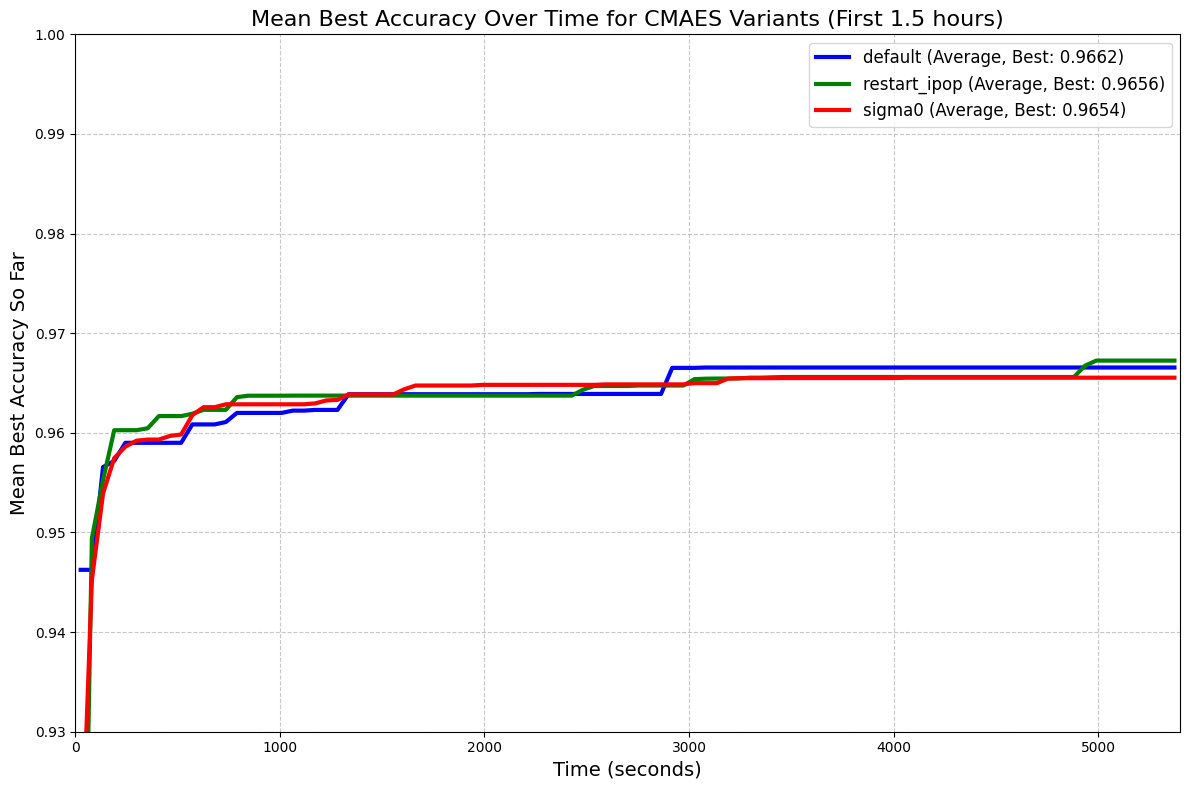

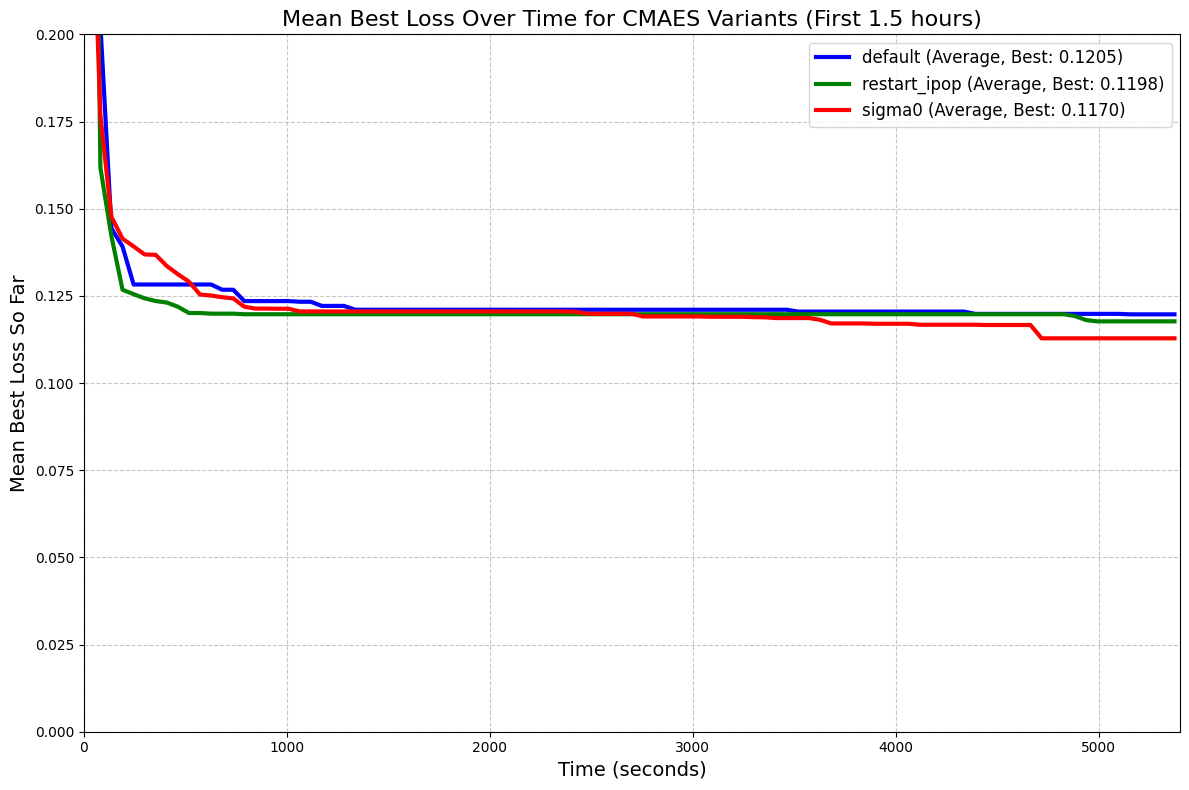

CMAES Variant Comparison (First 1.5 hours):
--------------------------------------------------
DEFAULT:
  Average Best Accuracy: 0.9662
  Average Best Loss: 0.1205
--------------------------------------------------
RESTART_IPOP:
  Average Best Accuracy: 0.9656
  Average Best Loss: 0.1198
--------------------------------------------------
SIGMA0:
  Average Best Accuracy: 0.9654
  Average Best Loss: 0.1170
--------------------------------------------------


In [13]:
# Load and compare CMAES variants
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Define CMAES variants to compare
cmaes_variants = ['default', 'restart_ipop', 'sigma0']
num_runs = 3  # Number of runs per variant
MAX_TIME = 5400  # 1.5 hours in seconds

# Dictionary to store results
cmaes_results = defaultdict(lambda: defaultdict(list))

# Load results for each variant and run
for variant in cmaes_variants:
    # For averaging across runs
    all_times = []
    all_accuracies = []
    all_losses = []
    
    for i in range(1, num_runs + 1):
        results_path = f"results/CMAES/{variant}/results_{i}.json"
        
        if os.path.exists(results_path):
            with open(results_path, 'r') as f:
                data = json.load(f)
            
            # Skip the first entry which contains metadata
            trial_data = data[1:]
            
            # Extract accuracies, losses and timestamps
            accuracies = []
            losses = []
            times = []
            
            best_accuracy_so_far = 0
            best_loss_so_far = float('inf')
            
            start_time = data[0].get('start_time', 0) if data else 0
            
            for trial in trial_data:
                trial_end = trial.get('trial_end', 0)
                elapsed_time = trial_end - start_time if trial_end and start_time else 0
                
                # Skip if beyond 1.5 hours
                if elapsed_time > MAX_TIME:
                    continue
                
                accuracy = trial.get('accuracy', 0)
                loss = trial.get('loss', float('inf'))
                
                # Track best values seen so far
                best_accuracy_so_far = max(best_accuracy_so_far, accuracy)
                best_loss_so_far = min(best_loss_so_far, loss)
                
                accuracies.append(best_accuracy_so_far)
                losses.append(best_loss_so_far)
                times.append(elapsed_time)
            
            if accuracies:
                all_times.extend(times)
                all_accuracies.extend(accuracies)
                all_losses.extend(losses)
            
            # Store final best values
            if accuracies:
                cmaes_results[variant]['accuracies'].append(max(accuracies))
            if losses:
                cmaes_results[variant]['losses'].append(min(losses))
    
    # Sort by time for each variant
    time_acc_pairs = sorted(zip(all_times, all_accuracies))
    time_loss_pairs = sorted(zip(all_times, all_losses))
    
    cmaes_results[variant]['time_acc_pairs'] = time_acc_pairs
    cmaes_results[variant]['time_loss_pairs'] = time_loss_pairs

# Calculate averages
for variant in cmaes_variants:
    cmaes_results[variant]['avg_accuracy'] = np.mean(cmaes_results[variant]['accuracies']) if cmaes_results[variant]['accuracies'] else 0
    cmaes_results[variant]['avg_loss'] = np.mean(cmaes_results[variant]['losses']) if cmaes_results[variant]['losses'] else float('inf')

# Plot average best accuracy over time
plt.figure(figsize=(12, 8))
colors = {'default': 'blue', 'restart_ipop': 'green', 'sigma0': 'red'}

for variant in cmaes_variants:
    if 'time_acc_pairs' in cmaes_results[variant] and cmaes_results[variant]['time_acc_pairs']:
        # Create bins for averaging
        max_time = MAX_TIME
        bins = np.linspace(0, max_time, 100)
        binned_accs = [[] for _ in range(len(bins)-1)]
        
        for t, acc in cmaes_results[variant]['time_acc_pairs']:
            if t <= MAX_TIME:
                bin_idx = min(int(t / max_time * (len(bins)-1)), len(bins)-2)
                binned_accs[bin_idx].append(acc)
        
        # For each bin, take the mean of best accuracies so far
        avg_accs = []
        best_so_far = 0
        
        for i, bin_accs in enumerate(binned_accs):
            if bin_accs:
                bin_best = np.mean(bin_accs)
                best_so_far = max(best_so_far, bin_best)
                avg_accs.append(best_so_far)
            elif i > 0 and avg_accs:  # Use previous value if bin is empty
                avg_accs.append(best_so_far)
            else:
                avg_accs.append(np.nan)
        
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        # Remove NaN values
        valid_indices = ~np.isnan(avg_accs)
        if any(valid_indices):
            plt.plot(bin_centers[valid_indices], np.array(avg_accs)[valid_indices], 
                    color=colors[variant], 
                    linewidth=3,
                    label=f"{variant} (Average, Best: {cmaes_results[variant]['avg_accuracy']:.4f})")

plt.xlabel('Time (seconds)', fontsize=14)
plt.ylabel('Mean Best Accuracy So Far', fontsize=14)
plt.title('Mean Best Accuracy Over Time for CMAES Variants (First 1.5 hours)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0.93, 1.0)  # Zoom in on high accuracy region
plt.xlim(0, MAX_TIME)  # Limit x-axis to 1.5 hours
plt.tight_layout()
plt.show()

# Plot average best loss over time
plt.figure(figsize=(12, 8))

for variant in cmaes_variants:
    if 'time_loss_pairs' in cmaes_results[variant] and cmaes_results[variant]['time_loss_pairs']:
        # Create bins for averaging
        max_time = MAX_TIME
        bins = np.linspace(0, max_time, 100)
        binned_losses = [[] for _ in range(len(bins)-1)]
        
        for t, loss in cmaes_results[variant]['time_loss_pairs']:
            if t <= MAX_TIME:
                bin_idx = min(int(t / max_time * (len(bins)-1)), len(bins)-2)
                binned_losses[bin_idx].append(loss)
        
        # For each bin, take the mean of best losses so far
        avg_losses = []
        best_so_far = float('inf')
        
        for i, bin_losses in enumerate(binned_losses):
            if bin_losses:
                bin_best = np.mean(bin_losses)
                best_so_far = min(best_so_far, bin_best)
                avg_losses.append(best_so_far)
            elif i > 0 and avg_losses:  # Use previous value if bin is empty
                avg_losses.append(best_so_far)
            else:
                avg_losses.append(np.nan)
        
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        # Remove NaN values
        valid_indices = ~np.isnan(avg_losses)
        if any(valid_indices):
            plt.plot(bin_centers[valid_indices], np.array(avg_losses)[valid_indices], 
                    color=colors[variant], 
                    linewidth=3,
                    label=f"{variant} (Average, Best: {cmaes_results[variant]['avg_loss']:.4f})")

plt.xlabel('Time (seconds)', fontsize=14)
plt.ylabel('Mean Best Loss So Far', fontsize=14)
plt.title('Mean Best Loss Over Time for CMAES Variants (First 1.5 hours)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0.0, 0.2)  # Zoom in on low loss region
plt.xlim(0, MAX_TIME)  # Limit x-axis to 1.5 hours
plt.tight_layout()
plt.show()

# Print detailed results
print("CMAES Variant Comparison (First 1.5 hours):")
print("-" * 50)
for variant in cmaes_variants:
    print(f"{variant.upper()}:")
    print(f"  Average Best Accuracy: {cmaes_results[variant]['avg_accuracy']:.4f}")
    print(f"  Average Best Loss: {cmaes_results[variant]['avg_loss']:.4f}")
    print("-" * 50)


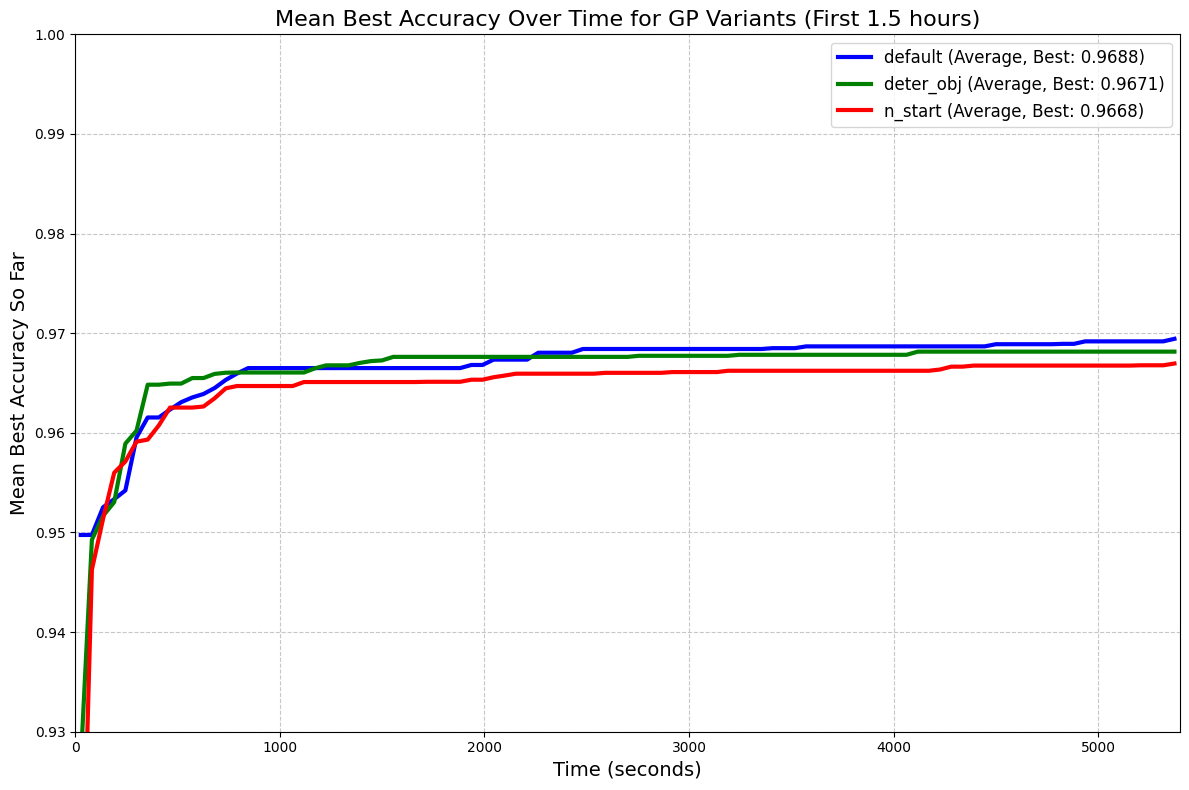

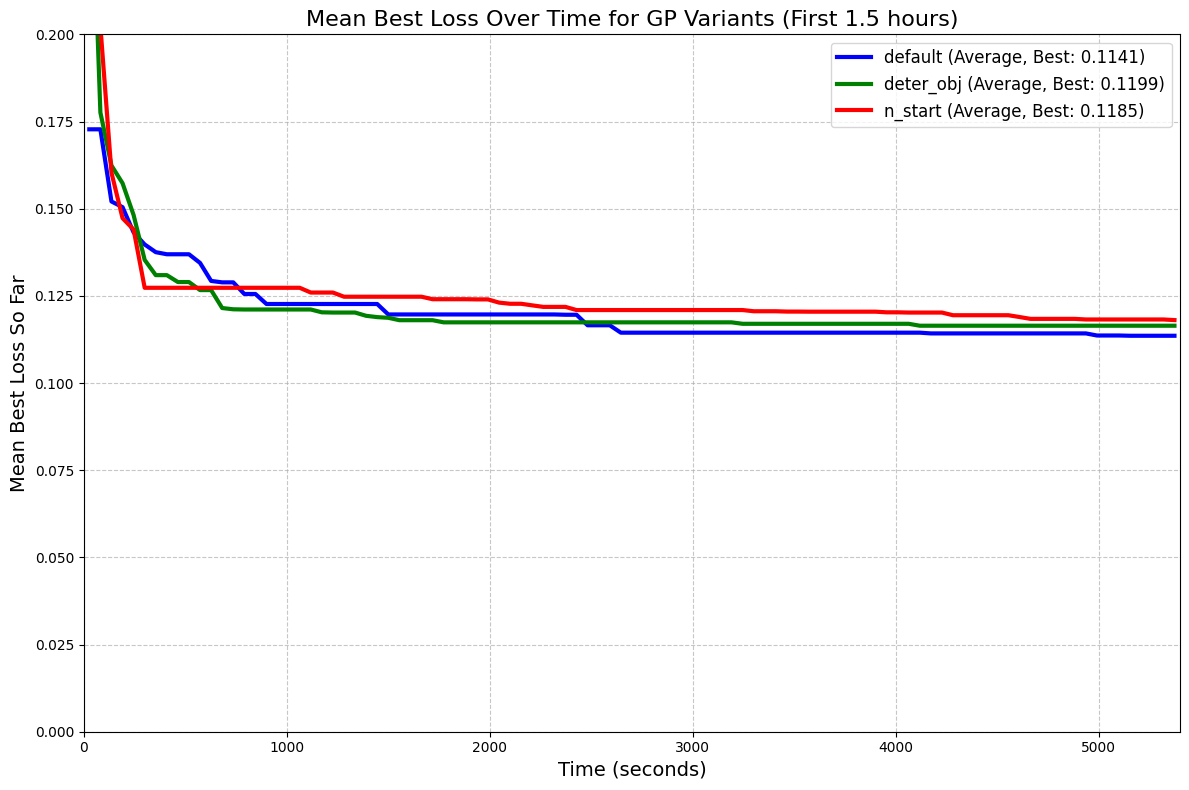

GP Variant Comparison (First 1.5 hours):
--------------------------------------------------
DEFAULT:
  Average Best Accuracy: 0.9688
  Average Best Loss: 0.1141
--------------------------------------------------
DETER_OBJ:
  Average Best Accuracy: 0.9671
  Average Best Loss: 0.1199
--------------------------------------------------
N_START:
  Average Best Accuracy: 0.9668
  Average Best Loss: 0.1185
--------------------------------------------------


In [14]:
# Load and compare GP variants
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Define GP variants to compare
gp_variants = ['default', 'deter_obj', 'n_start']
num_runs = 3  # Number of runs per variant
MAX_TIME = 5400  # 1.5 hours in seconds

# Dictionary to store results
gp_results = defaultdict(lambda: defaultdict(list))

# Load results for each variant and run
for variant in gp_variants:
    # For averaging across runs
    all_times = []
    all_accuracies = []
    all_losses = []
    
    for i in range(1, num_runs + 1):
        results_path = f"results/GP/{variant}/results_{i}.json"
        
        if os.path.exists(results_path):
            with open(results_path, 'r') as f:
                data = json.load(f)
            
            # Skip the first entry which contains metadata
            trial_data = data[1:]
            
            # Extract accuracies, losses and timestamps
            accuracies = []
            losses = []
            times = []
            
            best_accuracy_so_far = 0
            best_loss_so_far = float('inf')
            
            start_time = data[0].get('start_time', 0) if data else 0
            
            for trial in trial_data:
                trial_end = trial.get('trial_end', 0)
                elapsed_time = trial_end - start_time if trial_end and start_time else 0
                
                # Skip if beyond 1.5 hours
                if elapsed_time > MAX_TIME:
                    continue
                
                accuracy = trial.get('accuracy', 0)
                loss = trial.get('loss', float('inf'))
                
                # Track best values seen so far
                best_accuracy_so_far = max(best_accuracy_so_far, accuracy)
                best_loss_so_far = min(best_loss_so_far, loss)
                
                accuracies.append(best_accuracy_so_far)
                losses.append(best_loss_so_far)
                times.append(elapsed_time)
            
            if accuracies:
                all_times.extend(times)
                all_accuracies.extend(accuracies)
                all_losses.extend(losses)
            
            # Store final best values
            if accuracies:
                gp_results[variant]['accuracies'].append(max(accuracies))
            if losses:
                gp_results[variant]['losses'].append(min(losses))
    
    # Sort by time for each variant
    time_acc_pairs = sorted(zip(all_times, all_accuracies))
    time_loss_pairs = sorted(zip(all_times, all_losses))
    
    gp_results[variant]['time_acc_pairs'] = time_acc_pairs
    gp_results[variant]['time_loss_pairs'] = time_loss_pairs

# Calculate averages
for variant in gp_variants:
    gp_results[variant]['avg_accuracy'] = np.mean(gp_results[variant]['accuracies']) if gp_results[variant]['accuracies'] else 0
    gp_results[variant]['avg_loss'] = np.mean(gp_results[variant]['losses']) if gp_results[variant]['losses'] else float('inf')

# Plot average best accuracy over time
plt.figure(figsize=(12, 8))
colors = {'default': 'blue', 'deter_obj': 'green', 'n_start': 'red'}

for variant in gp_variants:
    if 'time_acc_pairs' in gp_results[variant] and gp_results[variant]['time_acc_pairs']:
        # Create bins for averaging
        max_time = MAX_TIME
        bins = np.linspace(0, max_time, 100)
        binned_accs = [[] for _ in range(len(bins)-1)]
        
        for t, acc in gp_results[variant]['time_acc_pairs']:
            if t <= MAX_TIME:
                bin_idx = min(int(t / max_time * (len(bins)-1)), len(bins)-2)
                binned_accs[bin_idx].append(acc)
        
        # For each bin, take the mean of best accuracies so far
        avg_accs = []
        best_so_far = 0
        
        for i, bin_accs in enumerate(binned_accs):
            if bin_accs:
                bin_best = np.mean(bin_accs)
                best_so_far = max(best_so_far, bin_best)
                avg_accs.append(best_so_far)
            elif i > 0 and avg_accs:  # Use previous value if bin is empty
                avg_accs.append(best_so_far)
            else:
                avg_accs.append(np.nan)
        
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        # Remove NaN values
        valid_indices = ~np.isnan(avg_accs)
        if any(valid_indices):
            plt.plot(bin_centers[valid_indices], np.array(avg_accs)[valid_indices], 
                    color=colors[variant], 
                    linewidth=3,
                    label=f"{variant} (Average, Best: {gp_results[variant]['avg_accuracy']:.4f})")

plt.xlabel('Time (seconds)', fontsize=14)
plt.ylabel('Mean Best Accuracy So Far', fontsize=14)
plt.title('Mean Best Accuracy Over Time for GP Variants (First 1.5 hours)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0.93, 1.0)  # Zoom in on high accuracy region
plt.xlim(0, MAX_TIME)  # Limit x-axis to 1.5 hours
plt.tight_layout()
plt.show()

# Plot average best loss over time
plt.figure(figsize=(12, 8))

for variant in gp_variants:
    if 'time_loss_pairs' in gp_results[variant] and gp_results[variant]['time_loss_pairs']:
        # Create bins for averaging
        max_time = MAX_TIME
        bins = np.linspace(0, max_time, 100)
        binned_losses = [[] for _ in range(len(bins)-1)]
        
        for t, loss in gp_results[variant]['time_loss_pairs']:
            if t <= MAX_TIME:
                bin_idx = min(int(t / max_time * (len(bins)-1)), len(bins)-2)
                binned_losses[bin_idx].append(loss)
        
        # For each bin, take the mean of best losses so far
        avg_losses = []
        best_so_far = float('inf')
        
        for i, bin_losses in enumerate(binned_losses):
            if bin_losses:
                bin_best = np.mean(bin_losses)
                best_so_far = min(best_so_far, bin_best)
                avg_losses.append(best_so_far)
            elif i > 0 and avg_losses:  # Use previous value if bin is empty
                avg_losses.append(best_so_far)
            else:
                avg_losses.append(np.nan)
        
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        # Remove NaN values
        valid_indices = ~np.isnan(avg_losses)
        if any(valid_indices):
            plt.plot(bin_centers[valid_indices], np.array(avg_losses)[valid_indices], 
                    color=colors[variant], 
                    linewidth=3,
                    label=f"{variant} (Average, Best: {gp_results[variant]['avg_loss']:.4f})")

plt.xlabel('Time (seconds)', fontsize=14)
plt.ylabel('Mean Best Loss So Far', fontsize=14)
plt.title('Mean Best Loss Over Time for GP Variants (First 1.5 hours)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0.0, 0.2)  # Zoom in on low loss region
plt.xlim(0, MAX_TIME)  # Limit x-axis to 1.5 hours
plt.tight_layout()
plt.show()

# Print detailed results
print("GP Variant Comparison (First 1.5 hours):")
print("-" * 50)
for variant in gp_variants:
    print(f"{variant.upper()}:")
    print(f"  Average Best Accuracy: {gp_results[variant]['avg_accuracy']:.4f}")
    print(f"  Average Best Loss: {gp_results[variant]['avg_loss']:.4f}")
    print("-" * 50)


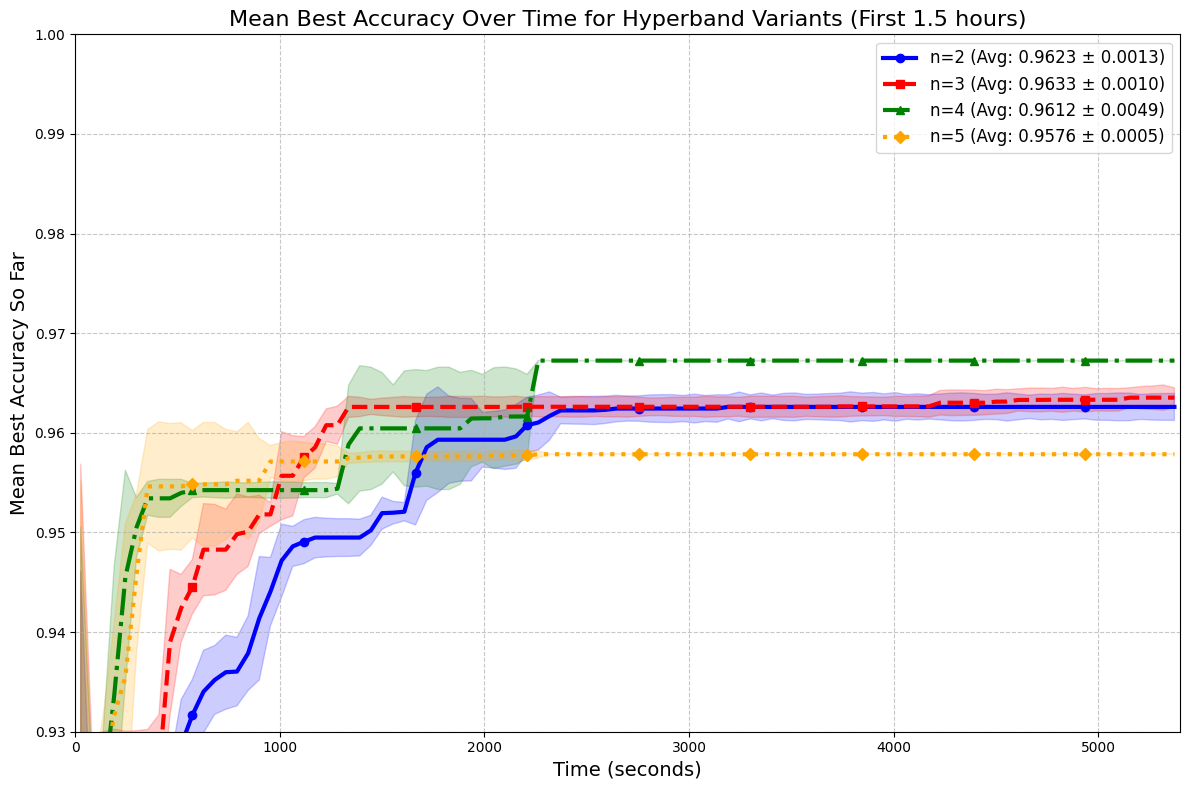

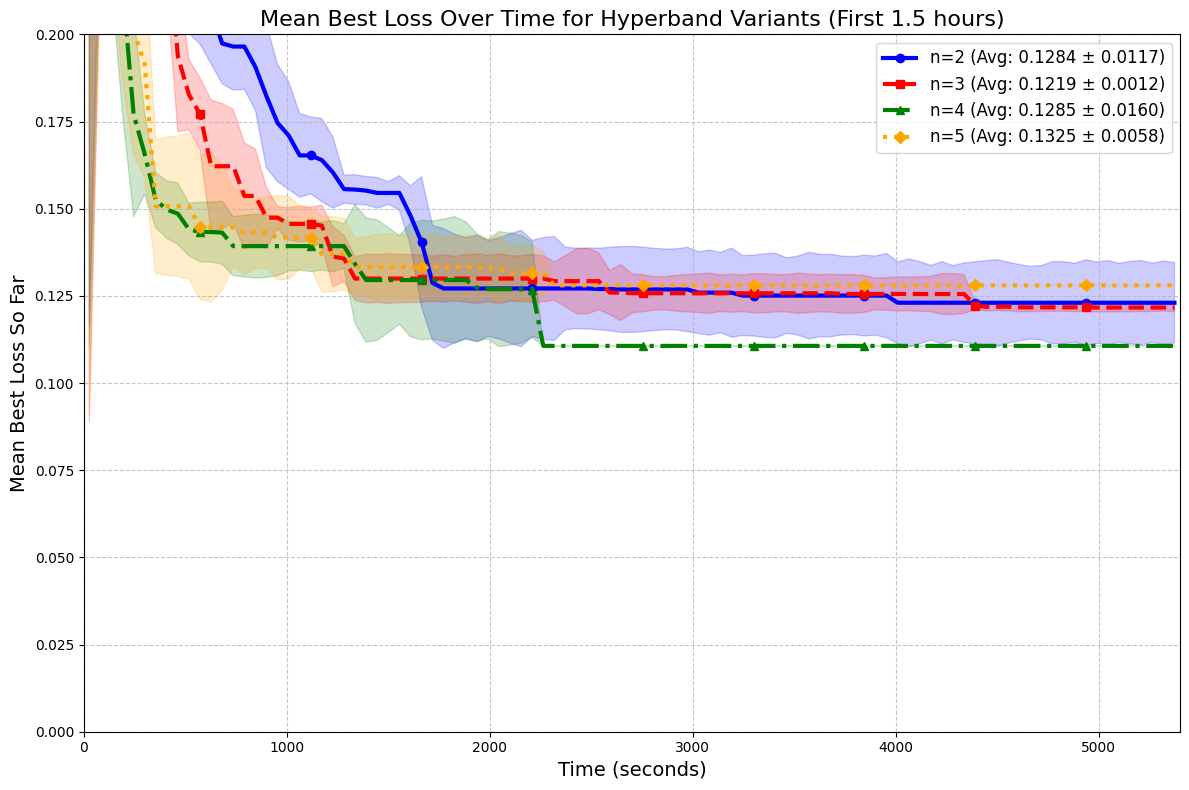

Hyperband Variant Comparison (First 1.5 hours):
--------------------------------------------------
N=2:
  Average Best Accuracy: 0.9623 ± 0.0013
  Average Best Loss: 0.1284 ± 0.0117
--------------------------------------------------
N=3:
  Average Best Accuracy: 0.9633 ± 0.0010
  Average Best Loss: 0.1219 ± 0.0012
--------------------------------------------------
N=4:
  Average Best Accuracy: 0.9612 ± 0.0049
  Average Best Loss: 0.1285 ± 0.0160
--------------------------------------------------
N=5:
  Average Best Accuracy: 0.9576 ± 0.0005
  Average Best Loss: 0.1325 ± 0.0058
--------------------------------------------------


In [2]:
# Load and compare Hyperband variants
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Define Hyperband variants to compare
hyperband_variants = ['n=2', 'n=3', 'n=4', 'n=5']  # All available variants
num_runs = 3  # Number of runs per variant
MAX_TIME = 5400  # 1.5 hours in seconds

# Dictionary to store results
hyperband_results = defaultdict(lambda: defaultdict(list))

# Load results for each variant and run
for variant in hyperband_variants:
    # For averaging across runs
    all_times = []
    all_accuracies = []
    all_losses = []
    
    for i in range(1, num_runs + 1):
        results_path = f"results/HYPERBAND/{variant}/results_{i}.json"
        
        if os.path.exists(results_path):
            try:
                with open(results_path, 'r') as f:
                    data = json.load(f)
                
                # Extract accuracies, losses and timestamps
                accuracies = []
                losses = []
                times = []
                
                best_accuracy_so_far = 0
                best_loss_so_far = float('inf')
                
                # Find the start time
                start_time = None
                for entry in data:
                    if 'start_time' in entry:
                        start_time = entry['start_time']
                        break
                
                if start_time is None and data:
                    # If no explicit start_time, use the first trial's end time minus a small offset
                    for entry in data:
                        if 'trial_end' in entry:
                            start_time = entry['trial_end'] - 1
                            break
                
                if start_time is None:
                    continue  # Skip this file if we can't determine start time
                
                # Process trial data
                for entry in data:
                    if 'trial_end' not in entry or 'accuracy' not in entry:
                        continue
                    
                    trial_end = entry['trial_end']
                    elapsed_time = trial_end - start_time
                    
                    # Skip if beyond 1.5 hours
                    if elapsed_time > MAX_TIME:
                        continue
                    
                    accuracy = entry['accuracy']
                    loss = entry.get('loss', float('inf'))
                    
                    # Track best values seen so far
                    best_accuracy_so_far = max(best_accuracy_so_far, accuracy)
                    best_loss_so_far = min(best_loss_so_far, loss)
                    
                    accuracies.append(best_accuracy_so_far)
                    losses.append(best_loss_so_far)
                    times.append(elapsed_time)
                
                if accuracies:
                    all_times.extend(times)
                    all_accuracies.extend(accuracies)
                    all_losses.extend(losses)
                
                # Store final best values
                if accuracies:
                    hyperband_results[variant]['accuracies'].append(max(accuracies))
                if losses:
                    hyperband_results[variant]['losses'].append(min(losses))
            except Exception as e:
                print(f"Error loading {results_path}: {e}")
    
    # Sort by time for each variant
    if all_times and all_accuracies and all_losses:
        time_acc_pairs = sorted(zip(all_times, all_accuracies))
        time_loss_pairs = sorted(zip(all_times, all_losses))
        
        hyperband_results[variant]['time_acc_pairs'] = time_acc_pairs
        hyperband_results[variant]['time_loss_pairs'] = time_loss_pairs

# Calculate averages and standard deviations
for variant in hyperband_variants:
    hyperband_results[variant]['avg_accuracy'] = np.mean(hyperband_results[variant]['accuracies']) if hyperband_results[variant]['accuracies'] else 0
    hyperband_results[variant]['std_accuracy'] = np.std(hyperband_results[variant]['accuracies']) if hyperband_results[variant]['accuracies'] else 0
    hyperband_results[variant]['avg_loss'] = np.mean(hyperband_results[variant]['losses']) if hyperband_results[variant]['losses'] else float('inf')
    hyperband_results[variant]['std_loss'] = np.std(hyperband_results[variant]['losses']) if hyperband_results[variant]['losses'] else 0

# Check if we have any data to plot
has_data = False
for variant in hyperband_variants:
    if 'time_acc_pairs' in hyperband_results[variant] and hyperband_results[variant]['time_acc_pairs']:
        has_data = True
        break

if has_data:
    # Plot average best accuracy over time
    plt.figure(figsize=(12, 8))
    colors = {'n=2': 'blue', 'n=3': 'red', 'n=4': 'green', 'n=5': 'orange'}
    line_styles = {'n=2': '-', 'n=3': '--', 'n=4': '-.', 'n=5': ':'}
    marker_styles = {'n=2': 'o', 'n=3': 's', 'n=4': '^', 'n=5': 'D'}

    for variant in hyperband_variants:
        if 'time_acc_pairs' in hyperband_results[variant] and hyperband_results[variant]['time_acc_pairs']:
            # Create bins for averaging
            max_time = MAX_TIME
            bins = np.linspace(0, max_time, 100)
            binned_accs = [[] for _ in range(len(bins)-1)]
            
            for t, acc in hyperband_results[variant]['time_acc_pairs']:
                if t <= MAX_TIME:
                    bin_idx = min(int(t / max_time * (len(bins)-1)), len(bins)-2)
                    binned_accs[bin_idx].append(acc)
            
            # For each bin, take the mean and std of best accuracies so far
            avg_accs = []
            std_accs = []
            best_so_far = 0
            
            for i, bin_accs in enumerate(binned_accs):
                if bin_accs:
                    bin_best = np.mean(bin_accs)
                    bin_std = np.std(bin_accs)
                    best_so_far = max(best_so_far, bin_best)
                    avg_accs.append(best_so_far)
                    std_accs.append(bin_std)
                elif i > 0 and avg_accs:  # Use previous value if bin is empty
                    avg_accs.append(best_so_far)
                    std_accs.append(std_accs[-1] if std_accs else 0)
                else:
                    avg_accs.append(np.nan)
                    std_accs.append(np.nan)
            
            bin_centers = (bins[:-1] + bins[1:]) / 2
            
            # Remove NaN values
            valid_indices = ~np.isnan(avg_accs)
            if any(valid_indices):
                mean_line = plt.plot(bin_centers[valid_indices], np.array(avg_accs)[valid_indices], 
                        color=colors[variant], 
                        linestyle=line_styles[variant],
                        marker=marker_styles[variant],
                        markevery=10,
                        linewidth=3,
                        label=f"{variant} (Avg: {hyperband_results[variant]['avg_accuracy']:.4f} ± {hyperband_results[variant]['std_accuracy']:.4f})")
                
                # Add shaded region for standard deviation if we have valid std values
                valid_std_indices = valid_indices & ~np.isnan(std_accs)
                if any(valid_std_indices):
                    plt.fill_between(
                        bin_centers[valid_std_indices],
                        np.array(avg_accs)[valid_std_indices] - np.array(std_accs)[valid_std_indices],
                        np.array(avg_accs)[valid_std_indices] + np.array(std_accs)[valid_std_indices],
                        color=colors[variant],
                        alpha=0.2
                    )

    plt.xlabel('Time (seconds)', fontsize=14)
    plt.ylabel('Mean Best Accuracy So Far', fontsize=14)
    plt.title('Mean Best Accuracy Over Time for Hyperband Variants (First 1.5 hours)', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.ylim(0.93, 1.0)  # Zoom in on high accuracy region
    plt.xlim(0, MAX_TIME)  # Limit x-axis to 1.5 hours
    plt.tight_layout()
    plt.show()

    # Plot average best loss over time
    plt.figure(figsize=(12, 8))

    for variant in hyperband_variants:
        if 'time_loss_pairs' in hyperband_results[variant] and hyperband_results[variant]['time_loss_pairs']:
            # Create bins for averaging
            max_time = MAX_TIME
            bins = np.linspace(0, max_time, 100)
            binned_losses = [[] for _ in range(len(bins)-1)]
            
            for t, loss in hyperband_results[variant]['time_loss_pairs']:
                if t <= MAX_TIME:
                    bin_idx = min(int(t / max_time * (len(bins)-1)), len(bins)-2)
                    binned_losses[bin_idx].append(loss)
            
            # For each bin, take the mean and std of best losses so far
            avg_losses = []
            std_losses = []
            best_so_far = float('inf')
            
            for i, bin_losses in enumerate(binned_losses):
                if bin_losses:
                    bin_best = np.mean(bin_losses)
                    bin_std = np.std(bin_losses)
                    best_so_far = min(best_so_far, bin_best)
                    avg_losses.append(best_so_far)
                    std_losses.append(bin_std)
                elif i > 0 and avg_losses:  # Use previous value if bin is empty
                    avg_losses.append(best_so_far)
                    std_losses.append(std_losses[-1] if std_losses else 0)
                else:
                    avg_losses.append(np.nan)
                    std_losses.append(np.nan)
            
            bin_centers = (bins[:-1] + bins[1:]) / 2
            
            # Remove NaN values
            valid_indices = ~np.isnan(avg_losses)
            if any(valid_indices):
                mean_line = plt.plot(bin_centers[valid_indices], np.array(avg_losses)[valid_indices], 
                        color=colors[variant], 
                        linestyle=line_styles[variant],
                        marker=marker_styles[variant],
                        markevery=10,
                        linewidth=3,
                        label=f"{variant} (Avg: {hyperband_results[variant]['avg_loss']:.4f} ± {hyperband_results[variant]['std_loss']:.4f})")
                
                # Add shaded region for standard deviation if we have valid std values
                valid_std_indices = valid_indices & ~np.isnan(std_losses)
                if any(valid_std_indices):
                    plt.fill_between(
                        bin_centers[valid_std_indices],
                        np.array(avg_losses)[valid_std_indices] - np.array(std_losses)[valid_std_indices],
                        np.array(avg_losses)[valid_std_indices] + np.array(std_losses)[valid_std_indices],
                        color=colors[variant],
                        alpha=0.2
                    )

    plt.xlabel('Time (seconds)', fontsize=14)
    plt.ylabel('Mean Best Loss So Far', fontsize=14)
    plt.title('Mean Best Loss Over Time for Hyperband Variants (First 1.5 hours)', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.ylim(0.0, 0.2)  # Zoom in on low loss region
    plt.xlim(0, MAX_TIME)  # Limit x-axis to 1.5 hours
    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot for Hyperband variants.")

# Print detailed results
print("Hyperband Variant Comparison (First 1.5 hours):")
print("-" * 50)
for variant in hyperband_variants:
    print(f"{variant.upper()}:")
    print(f"  Average Best Accuracy: {hyperband_results[variant]['avg_accuracy']:.4f} ± {hyperband_results[variant]['std_accuracy']:.4f}")
    print(f"  Average Best Loss: {hyperband_results[variant]['avg_loss']:.4f} ± {hyperband_results[variant]['std_loss']:.4f}")
    print("-" * 50)


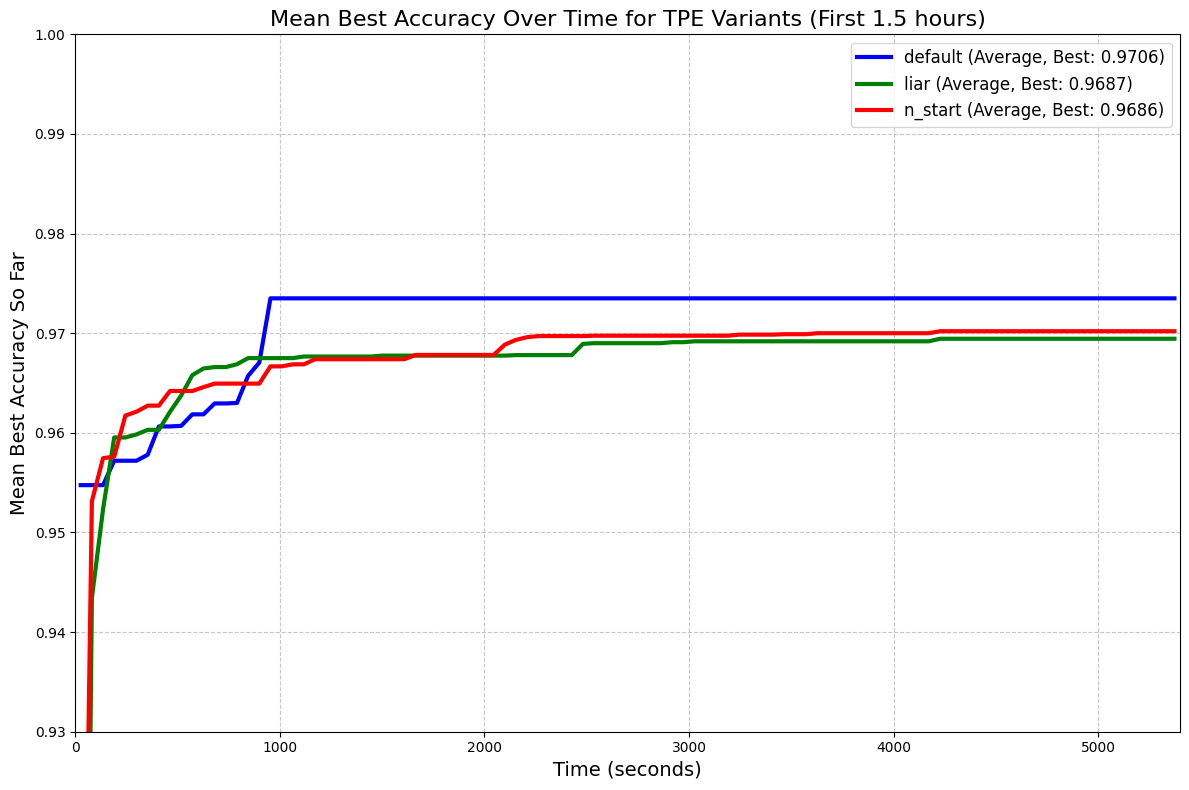

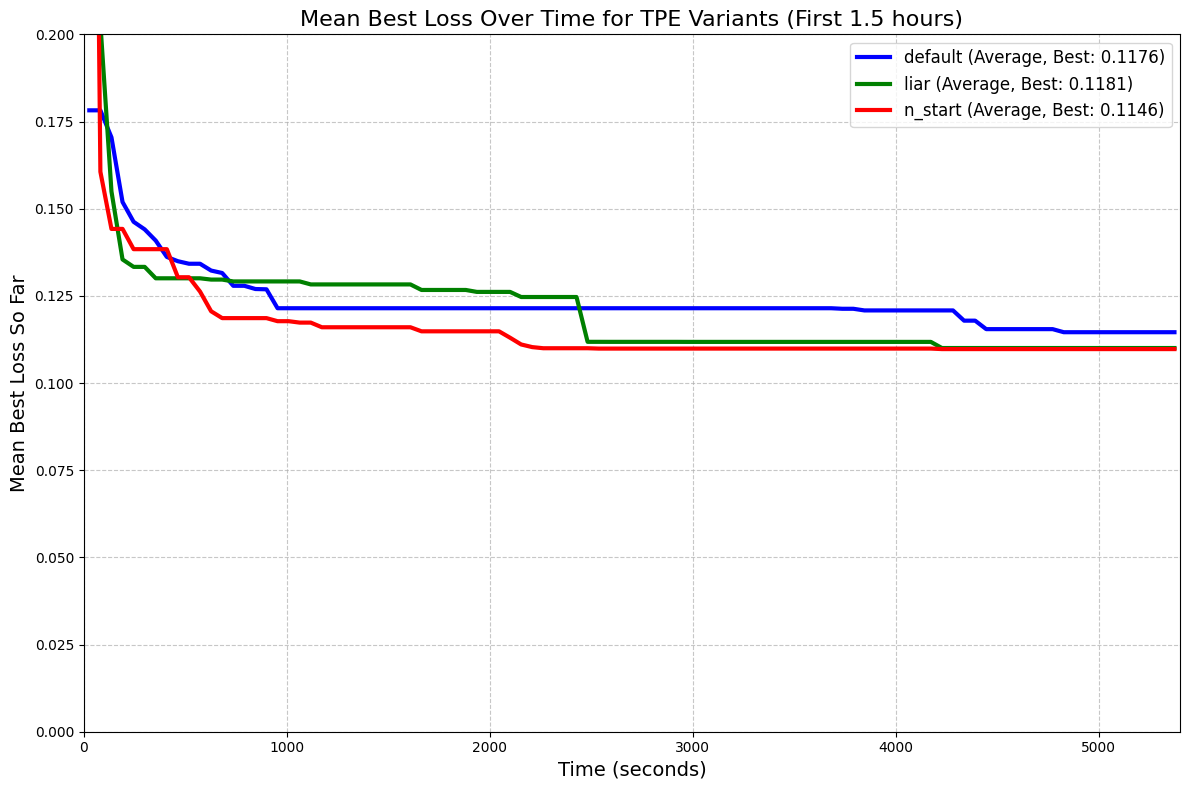

TPE Variant Comparison (First 1.5 hours):
--------------------------------------------------
DEFAULT:
  Average Best Accuracy: 0.9706
  Average Best Loss: 0.1176
--------------------------------------------------
LIAR:
  Average Best Accuracy: 0.9687
  Average Best Loss: 0.1181
--------------------------------------------------
N_START:
  Average Best Accuracy: 0.9686
  Average Best Loss: 0.1146
--------------------------------------------------


: 

In [21]:
# Load and compare TPE variants
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Define TPE variants to compare
tpe_variants = ['default', 'liar', 'n_start']
num_runs = 3  # Number of runs per variant
MAX_TIME = 5400  # 1.5 hours in seconds

# Dictionary to store results
tpe_results = defaultdict(lambda: defaultdict(list))

# Load results for each variant and run
for variant in tpe_variants:
    # For averaging across runs
    all_times = []
    all_accuracies = []
    all_losses = []
    
    for i in range(1, num_runs + 1):
        results_path = f"results/TPE/{variant}/results_{i}.json"
        
        if os.path.exists(results_path):
            with open(results_path, 'r') as f:
                data = json.load(f)
            
            # Skip the first entry which contains metadata
            trial_data = data[1:]
            
            # Extract accuracies, losses and timestamps
            accuracies = []
            losses = []
            times = []
            
            best_accuracy_so_far = 0
            best_loss_so_far = float('inf')
            
            start_time = data[0].get('start_time', 0) if data else 0
            
            for trial in trial_data:
                trial_end = trial.get('trial_end', 0)
                elapsed_time = trial_end - start_time if trial_end and start_time else 0
                
                # Skip if beyond 1.5 hours
                if elapsed_time > MAX_TIME:
                    continue
                
                accuracy = trial.get('accuracy', 0)
                loss = trial.get('loss', float('inf'))
                
                # Track best values seen so far
                best_accuracy_so_far = max(best_accuracy_so_far, accuracy)
                best_loss_so_far = min(best_loss_so_far, loss)
                
                accuracies.append(best_accuracy_so_far)
                losses.append(best_loss_so_far)
                times.append(elapsed_time)
            
            if accuracies:
                all_times.extend(times)
                all_accuracies.extend(accuracies)
                all_losses.extend(losses)
            
            # Store final best values
            if accuracies:
                tpe_results[variant]['accuracies'].append(max(accuracies))
            if losses:
                tpe_results[variant]['losses'].append(min(losses))
    
    # Sort by time for each variant
    time_acc_pairs = sorted(zip(all_times, all_accuracies))
    time_loss_pairs = sorted(zip(all_times, all_losses))
    
    tpe_results[variant]['time_acc_pairs'] = time_acc_pairs
    tpe_results[variant]['time_loss_pairs'] = time_loss_pairs

# Calculate averages
for variant in tpe_variants:
    tpe_results[variant]['avg_accuracy'] = np.mean(tpe_results[variant]['accuracies']) if tpe_results[variant]['accuracies'] else 0
    tpe_results[variant]['avg_loss'] = np.mean(tpe_results[variant]['losses']) if tpe_results[variant]['losses'] else float('inf')

# Plot average best accuracy over time
plt.figure(figsize=(12, 8))
colors = {'default': 'blue', 'liar': 'green', 'n_start': 'red'}

for variant in tpe_variants:
    if 'time_acc_pairs' in tpe_results[variant] and tpe_results[variant]['time_acc_pairs']:
        # Create bins for averaging
        max_time = MAX_TIME
        bins = np.linspace(0, max_time, 100)
        binned_accs = [[] for _ in range(len(bins)-1)]
        
        for t, acc in tpe_results[variant]['time_acc_pairs']:
            if t <= MAX_TIME:
                bin_idx = min(int(t / max_time * (len(bins)-1)), len(bins)-2)
                binned_accs[bin_idx].append(acc)
        
        # For each bin, take the mean of best accuracies so far
        avg_accs = []
        best_so_far = 0
        
        for i, bin_accs in enumerate(binned_accs):
            if bin_accs:
                bin_best = np.mean(bin_accs)
                best_so_far = max(best_so_far, bin_best)
                avg_accs.append(best_so_far)
            elif i > 0 and avg_accs:  # Use previous value if bin is empty
                avg_accs.append(best_so_far)
            else:
                avg_accs.append(np.nan)
        
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        # Remove NaN values
        valid_indices = ~np.isnan(avg_accs)
        if any(valid_indices):
            plt.plot(bin_centers[valid_indices], np.array(avg_accs)[valid_indices], 
                    color=colors[variant], 
                    linewidth=3,
                    label=f"{variant} (Average, Best: {tpe_results[variant]['avg_accuracy']:.4f})")

plt.xlabel('Time (seconds)', fontsize=14)
plt.ylabel('Mean Best Accuracy So Far', fontsize=14)
plt.title('Mean Best Accuracy Over Time for TPE Variants (First 1.5 hours)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0.93, 1.0)  # Zoom in on high accuracy region
plt.xlim(0, MAX_TIME)  # Limit x-axis to 1.5 hours
plt.tight_layout()
plt.show()

# Plot average best loss over time
plt.figure(figsize=(12, 8))

for variant in tpe_variants:
    if 'time_loss_pairs' in tpe_results[variant] and tpe_results[variant]['time_loss_pairs']:
        # Create bins for averaging
        max_time = MAX_TIME
        bins = np.linspace(0, max_time, 100)
        binned_losses = [[] for _ in range(len(bins)-1)]
        
        for t, loss in tpe_results[variant]['time_loss_pairs']:
            if t <= MAX_TIME:
                bin_idx = min(int(t / max_time * (len(bins)-1)), len(bins)-2)
                binned_losses[bin_idx].append(loss)
        
        # For each bin, take the mean of best losses so far
        avg_losses = []
        best_so_far = float('inf')
        
        for i, bin_losses in enumerate(binned_losses):
            if bin_losses:
                bin_best = np.mean(bin_losses)
                best_so_far = min(best_so_far, bin_best)
                avg_losses.append(best_so_far)
            elif i > 0 and avg_losses:  # Use previous value if bin is empty
                avg_losses.append(best_so_far)
            else:
                avg_losses.append(np.nan)
        
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        # Remove NaN values
        valid_indices = ~np.isnan(avg_losses)
        if any(valid_indices):
            plt.plot(bin_centers[valid_indices], np.array(avg_losses)[valid_indices], 
                    color=colors[variant], 
                    linewidth=3,
                    label=f"{variant} (Average, Best: {tpe_results[variant]['avg_loss']:.4f})")

plt.xlabel('Time (seconds)', fontsize=14)
plt.ylabel('Mean Best Loss So Far', fontsize=14)
plt.title('Mean Best Loss Over Time for TPE Variants (First 1.5 hours)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0.0, 0.2)  # Zoom in on low loss region
plt.xlim(0, MAX_TIME)  # Limit x-axis to 1.5 hours
plt.tight_layout()
plt.show()

# Print detailed results
print("TPE Variant Comparison (First 1.5 hours):")
print("-" * 50)
for variant in tpe_variants:
    print(f"{variant.upper()}:")
    print(f"  Average Best Accuracy: {tpe_results[variant]['avg_accuracy']:.4f}")
    print(f"  Average Best Loss: {tpe_results[variant]['avg_loss']:.4f}")
    print("-" * 50)
